# Notebook 02: Descriptive Analysis and Modelling

Prediction of sensory panel scores for twelve Cheddar trials from four instrumental
modalities (physical texture, E-tongue, tribology, GC-MS).

**Taste and aroma models**

| Model | Algorithm | Feature selection | GC-MS representation | Features |
|---|---|---|---|---|
| M1 | Ridge | none | compounds | all modalities |
| M2 | Multi-task Elastic Net | none | compounds | all modalities |
| M3 | PLSR | none | compounds | all modalities |
| M4 | Multi-task Elastic Net | K sweep | compounds | all modalities |
| M5 | PLSR | K sweep | compounds | all modalities |
| M6 | Random Forest | K sweep | compounds | all modalities |
| M7 | Multi-task Elastic Net | K sweep | odour groups | all modalities |
| M8 | Single-task Elastic Net | K sweep per target | odour groups | all modalities |
| M9 | Multi-task Elastic Net | K sweep | compounds | without physical |
| M10 | Multi-task Elastic Net | K sweep | compounds | physical only |
| M11 | PLSR | K sweep | compounds | without physical |
| M12 | PLSR | K sweep | compounds | physical only |

**Quality models**

| Model | Algorithm | Targets | GC-MS representation | Features |
|---|---|---|---|---|
| N1 | PLSR | joint | compounds | all modalities |
| N2 | Multi-task Elastic Net | joint | compounds | all modalities |
| N3 | Random Forest | per target | compounds | all modalities |
| N4 | PLSR | joint | odour groups | all modalities |
| N5 | PLSR | two sub-groups | odour groups | all modalities (reference model) |
| N6, N7 | PLSR | two sub-groups | odour groups | without physical, physical only |
| N8, N9 | PLSR | two sub-groups | odour groups | without E-tongue, E-tongue only |
| N10, N11 | PLSR | two sub-groups | odour groups | without tribology, tribology only |
| N12, N13 | PLSR | two sub-groups | odour groups | without GC-MS, GC-MS only |

All models are evaluated with leave-one-out cross-validation. Feature selection,
standardisation and hyperparameter tuning are done inside each fold on the training
trials only. Two additional analyses of M4 are included in Section 9.6: feature ranking
by the maximum instead of the mean correlation, and a fit without cross-validation.

## 1 Setup

In [1]:
import textwrap
import warnings
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import ElasticNetCV, MultiTaskElasticNetCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid", palette="Set2")

### Configuration

In [2]:
# Input files
PANEL_PATH = "panel_cleaned.csv"  # output of Notebook 01
PHYSICAL_PATH = r"C:/Users/miria/Downloads/Data for dashboard.xlsx"
ETONGUE_PATH = r"C:/Users/miria/Downloads/E-tongue_16122025-MildCheddar_585_Estimated Value_Relative_Taste_Intensity_ID_dat.xlsx"
TRIBOLOGY_PATH = r"C:/Users/miria/Downloads/Cheese tribology tests data overview (before report).xlsx"
GCMS_PATH = r"C:/Users/miria/Downloads/SPME GC MS Cheese summary final (3).xlsx"
FLAVOUR_TREE_PATH = r"C:/Users/miria/Downloads/Academy_of_Cheese_Flavour_Trees_Updated.xlsx"

# Trials that are available in the panel data and in all four instrumental datasets
TRIALS = [
    "110001", "110002", "110009",
    "110019", "110020", "110021", "110022", "110023", "110024",
    "120003", "120004", "240988",
]

# Trials in the physical data that are four batches of trial 240988
BATCHES_OF_240988 = {"241026": 1, "241027": 2, "241031": 3, "241032": 4}

# Sensory targets: panel section -> target name
TASTE_TARGETS = {
    "Acid_Sour": "Acid/Sour",
    "Bitter": "Bitter",
    "Nose_Aroma_Intensity": "Nose Aroma Intensity",
    "Palate_Intensity": "Palate Intensity",
    "Salt": "Salt",
    "Savoury_Umami": "Savoury/Umami",
    "Sweet": "Sweet",
    "Trigeminal_Intensity": "Trigeminal Intensity",
}
QUALITY_TARGETS = {
    "Balance": "Balance",
    "Complexity": "Complexity",
    "Condition": "Condition",
    "Degree_of_Artificiality": "Degree of Artificiality",
    "Development": "Development",
    "Interest": "Interest",
    "Length": "Length",
    "Processed_Taste": "Processed Taste",
    "Satisfaction": "Satisfaction",
}

# Quality targets are also modelled in two sub-groups
OFF_FLAVOUR = ["Processed Taste", "Degree of Artificiality"]
SUBGROUPS = {
    "off-flavour": OFF_FLAVOUR,
    "holistic": [t for t in QUALITY_TARGETS.values() if t not in OFF_FLAVOUR],
}

# Instrumental features: name in the raw file -> feature name.
# The order of PHYSICAL_PARAMETERS is the column order of the feature matrices.
PHYSICAL_PARAMETERS = {
    "Adhesiveness (g.sec)": "adhesiveness",
    "Average extensibility (gf/mm)": "average extensibility",
    "Average viscosity (mPa.s)": "average viscosity",
    "Chewiness (g)": "chewiness",
    "Cohesion (%)": "cohesiveness",
    "Complex viscosity (Pa.s)": "complex viscosity",
    "Fat (%)": "fat",
    "Glass transition temperature (°C)": "glass transition temperature",
    "Gumminess (g)": "gumminess",
    "Hardness (g)": "hardness",
    "Max extensibility resistance (gf)": "max extensibility",
    "Melted adhesiveness (gf)": "melted adhesiveness",
    "Melting (cm)": "melting",
    "Melting speed (mm/min)": "melting speed",
    "Moisture (%)": "moisture",
    "Oiling (cm)": "oiling",
    "Resilience (%)": "resilience",
    "Springiness (%)": "springiness",
    "Viscosity max (η0 approx in mPa.s)": "max viscosity",
    "Viscosity min (η∞ approx in mPa.s)": "min viscosity",
}
ETONGUE_SENSORS = {
    "Sour_CA0": "sour",
    "Bitter_C00": "bitter",
    "Astringent_AE1": "astringent",
    "Umami_UM2": "umami",
    "Salty_CT0": "salty",
    "Bitter-Aft_C00": "bitter aftertaste",
    "Ast-Aft_AE1": "astringent aftertaste",
    "Umami-Aft_AAE": "umami aftertaste",
}
TRIBOLOGY_PARAMETERS = {
    "Width (µm)": "width (dry)",
    "Depth (µm)": "depth (dry)",
    "Vol (mm^3)": "volume (dry)",
    "Roughness as cut Sa (µm)": "roughness as cut (dry)",
    "Wear scar roughness Sa (µm)": "wear scar roughness (dry)",
    "COF all (mean average)": "COF (dry)",
    "COF forward direction (mean average)": "COF forward (dry)",
    "COF backward direction (mean average)": "COF backward (dry)",
    "Width (µm).1": "width (wet)",
    "Depth (µm).1": "depth (wet)",
    "vol (mm^3)": "volume (wet)",
    "Roughness as cut Sa (µm).1": "roughness as cut (wet)",
    "Wear scar roughness Sa (µm).1": "wear scar roughness (wet)",
    "COF all (mean average).1": "COF (wet)",
    "COF forward direction (mean average).1": "COF forward (wet)",
    "COF backward direction (mean average).1": "COF backward (wet)",
}

# GC-MS
GCMS_MIN_TRIALS = 6  # a compound is kept if it is detected in at least this many trials
COMPOUND_SYNONYMS = {  # spelling variants of the same compound in different trials
    "Butane, 2,3 dione": "2,3-Butanedione",
    "butanoic acid ethylester": "Butanoic acid, ethyl ester",
    "Hexanoic acid ethyl ester": "Hexanoic acid, ethyl ester",
    "2-nonanone": "2-Nonanone",
    "methaethiol": "Methanethiol",
    "methanethiol": "Methanethiol",
}
COMPOUND_NAMES = {  # common names used instead of the library names
    "hexanoic acid, ethyl ester": "ethyl hexanoate",
    "butanal, 3-methyl-": "3-methylbutanal",
}
EXCLUDED_ODOUR_GROUPS = ["savoury", "trigeminal"]
# Rows of the combined GC-MS table whose odour group is assigned manually
MANUAL_ODOUR_GROUPS = {"dairy": [444, 501, 529, 537], "animal/fungal/fermented": [519]}

# Modelling
RANDOM_STATE = 42
INNER_CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
MAX_PLS_COMPONENTS = 3
K_VALUES = range(2, 13)  # numbers of selected features tested in the K sweep
STABLE_MIN_FOLDS = 5     # a feature is called stable if selected in at least 5 of 12 folds
RIDGE_ALPHAS = np.logspace(-3, 3, 50)
ENET_PARAMS = dict(l1_ratio=[0.5, 0.7, 0.9], alphas=np.logspace(-3, 1, 60), cv=INNER_CV,
                   max_iter=20000, random_state=RANDOM_STATE)
RF_PARAMS = dict(n_estimators=100, max_depth=3, min_samples_leaf=2, random_state=RANDOM_STATE)

### Plot helpers

In [55]:
BOX_STYLE = dict(
    color="steelblue",
    medianprops={"color": "black", "linewidth": 2},
    boxprops={"alpha": 0.85},
    whiskerprops={"linewidth": 2.5, "color": "steelblue"},
    capprops={"linewidth": 2.5, "color": "steelblue"},
    flierprops={"marker": "o", "markerfacecolor": "steelblue",
                "markeredgecolor": "black", "markersize": 10},
)

# Typography of the model figures, matched to the LaTeX document
THESIS_STYLE = {
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
}


def wrap(labels, width=16):
    """Break long tick labels into several lines."""
    return [textwrap.fill(str(label), width, break_long_words=False) for label in labels]


def z_boxplot(data, xlabel, figsize, fontsize, rotation=45, rows=1):
    """Boxplots of the z-standardised columns of `data`, one box per column."""
    z = (data - data.mean()) / data.std()
    fig, axes = plt.subplots(rows, 1, figsize=figsize, squeeze=False)
    for ax, columns in zip(axes.ravel(), np.array_split(np.array(z.columns), rows)):
        sns.boxplot(data=z[columns], ax=ax, **BOX_STYLE)
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_xticks(range(len(columns)))
        ax.set_xticklabels(wrap(columns), rotation=rotation)
        ax.set_xlabel("")
        ax.set_ylabel("Z-Score", fontsize=fontsize)
        ax.tick_params(labelsize=fontsize - 2)
    axes[-1, 0].set_xlabel(xlabel, fontsize=fontsize)
    sns.despine()
    plt.tight_layout()
    plt.show()


def correlation_heatmap(corr, figsize, fontsize, xlabel="", ylabel="", rotation=90):
    """Annotated heatmap of a correlation matrix."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.4,
                square=corr.shape[0] == corr.shape[1], annot_kws={"size": fontsize - 2},
                xticklabels=wrap(corr.columns), yticklabels=wrap(corr.index),
                cbar_kws={"shrink": 0.8}, ax=ax)
    ax.tick_params(axis="x", rotation=rotation, labelsize=fontsize)
    ax.tick_params(axis="y", rotation=0, labelsize=fontsize)
    ax.set_xlabel(xlabel, fontsize=fontsize + 3)
    ax.set_ylabel(ylabel, fontsize=fontsize + 3)
    colorbar = ax.collections[0].colorbar
    colorbar.set_label("Correlation", fontsize=fontsize)
    colorbar.ax.tick_params(labelsize=fontsize - 3)
    plt.tight_layout()
    plt.show()

## 2 Sensory panel data

Only the 17 modelled targets are kept. Two types of rows are removed: comment rows,
which carry no grade, and rows with status 3, where tasters changed their grade after
the brands had been revealed.

In [4]:
panel = pd.read_csv(PANEL_PATH, dtype={"Trial": str})
panel["Grade"] = pd.to_numeric(panel["Grade"], errors="coerce")
panel["Status"] = pd.to_numeric(panel["Status"], errors="coerce").astype("Int64")
panel["Criteria"] = panel["Criteria"].astype("string")
panel["Target"] = panel["Section"].map({**TASTE_TARGETS, **QUALITY_TARGETS})
print(f"Rows loaded: {len(panel):,}")

panel = panel[panel["Target"].notna()]
panel = panel[panel["Criteria"] != "Comment"]
print("Rows with status 3 per target:")
display(panel.loc[panel["Status"] == 3, "Target"].value_counts())
panel = panel[panel["Status"] != 3]
print(f"Rows used: {len(panel):,} | trials: {panel['Trial'].nunique()} | "
      f"targets: {panel['Target'].nunique()}")

# Model targets: mean grade of all tasters per trial and target
scores = panel.groupby(["Trial", "Target"])["Grade"].mean().unstack()
Y_taste = scores[list(TASTE_TARGETS.values())]
Y_quality = scores[list(QUALITY_TARGETS.values())]

Rows loaded: 3,649
Rows with status 3 per target:


Target
Satisfaction    1
Interest        1
Name: count, dtype: int64

Rows used: 1,015 | trials: 12 | targets: 17


### 2.1 Individual grades (taster level)

,Count,Pct (%)
Grade,,
0.0,56,5.517241
0.5,3,0.295567
1.0,107,10.541872
1.5,4,0.394089
2.0,339,33.399015
2.5,8,0.788177
3.0,317,31.231527
3.5,9,0.886700
4.0,153,15.073892


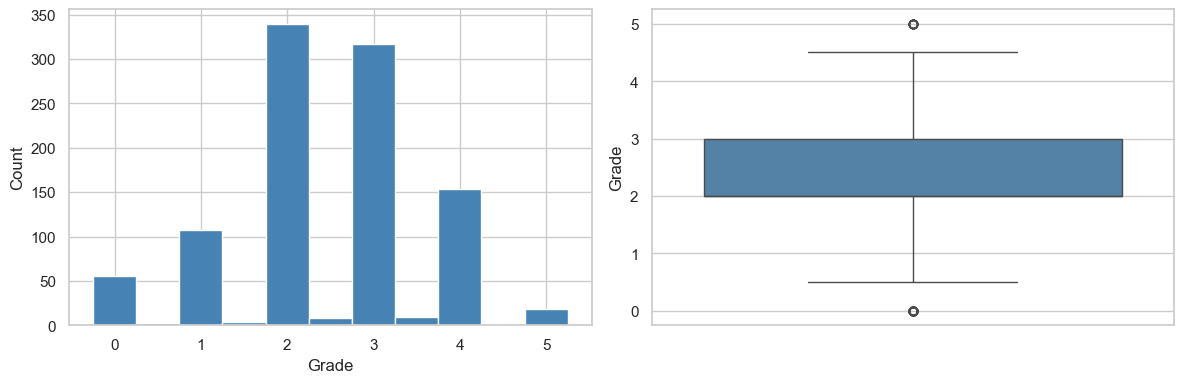

Grades per taster:


Taster
DB    204
BP    203
LH    203
PM    203
CT    202
Name: count, dtype: int64

Grades per status:


Status
1    948
2     67
Name: count, dtype: Int64

In [5]:
# Distribution of all grades
grades = panel["Grade"]
display(pd.DataFrame({"Count": grades.value_counts().sort_index(),
                      "Pct (%)": grades.value_counts(normalize=True).sort_index() * 100}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(grades.dropna(), bins=11, range=(-0.25, 5.25), color="steelblue", edgecolor="white")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Count")
sns.boxplot(y=grades, ax=axes[1], color="steelblue")
plt.tight_layout()
plt.show()

print("Grades per taster:")
display(panel["Taster"].value_counts())
print("Grades per status:")
display(panel["Status"].value_counts())

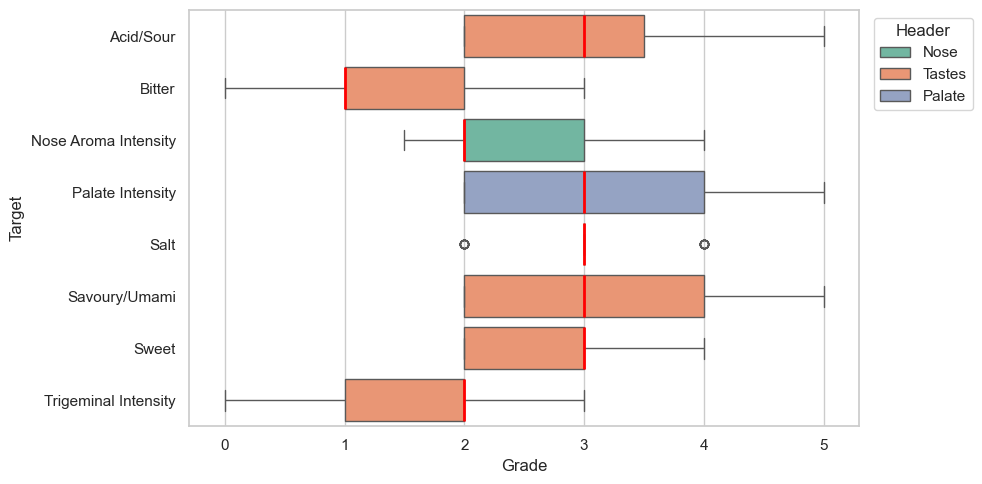

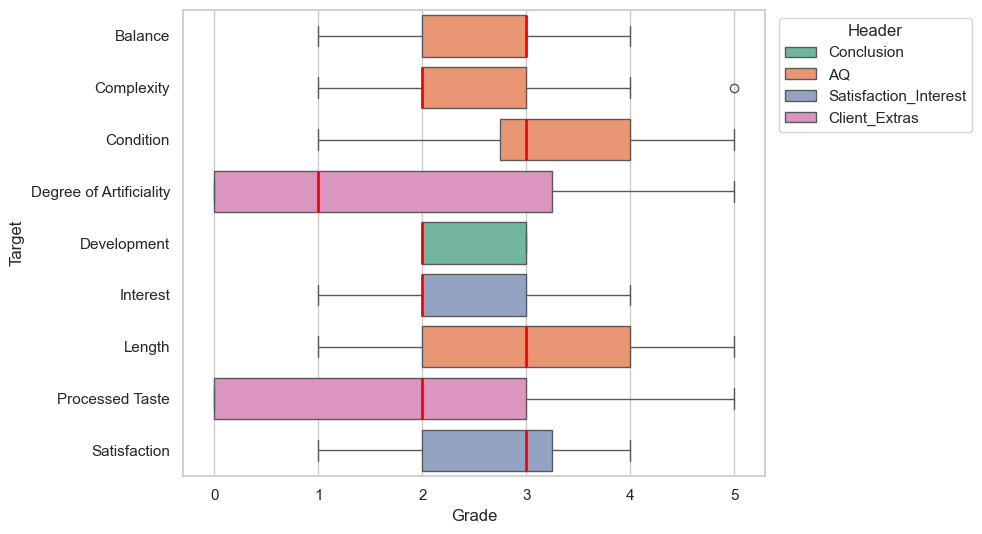

In [6]:
# Grade distribution per target
for targets in (Y_taste.columns, Y_quality.columns):
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(targets) + 1))
    sns.boxplot(data=panel[panel["Target"].isin(targets)], x="Grade", y="Target", hue="Header",
                dodge=False, order=sorted(targets), medianprops={"color": "red", "linewidth": 2}, ax=ax)
    ax.set_xlim(-0.3, 5.3)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Header")
    plt.tight_layout()
    plt.show()

In [7]:
# Spread of the individual grades per target (a higher CV means more disagreement)
taster_stats = panel.groupby("Target")["Grade"].agg(Mean="mean", Std="std", N="count")
taster_stats["CV (%)"] = (taster_stats["Std"] / taster_stats["Mean"] * 100).round(1)
display(taster_stats.sort_values("CV (%)", ascending=False))

# Many tasters gave a grade of 0 for the two off-flavour targets
for target in OFF_FLAVOUR:
    display(panel.loc[panel["Target"] == target, "Grade"].value_counts().rename(target).to_frame())

,Mean,Std,N,CV (%)
Target,,,,
Degree of Artificiality,1.666667,1.721417,60,103.3
Processed Taste,1.791667,1.769065,60,98.7
Bitter,1.141667,0.725397,60,63.5
Trigeminal Intensity,1.691667,0.765194,60,45.2
Interest,2.254237,0.882653,59,39.2
Complexity,2.433333,0.945402,60,38.9
Length,2.800000,1.005072,60,35.9
Satisfaction,2.813559,0.932638,59,33.1
Balance,2.750000,0.894901,60,32.5


,Processed Taste
Grade,
0.0,21
2.0,14
1.0,7
4.0,7
5.0,7
3.0,3
0.5,1


,Degree of Artificiality
Grade,
0.0,21
1.0,11
4.0,11
2.0,9
5.0,4
0.5,2
3.0,2


In [8]:
# Inter-rater agreement: mean pairwise Pearson correlation between tasters across trials
def mean_pairwise_correlation(target_rows):
    by_taster = target_rows.pivot_table(index="Trial", columns="Taster", values="Grade")
    correlations = [by_taster[a].corr(by_taster[b])
                    for a, b in combinations(by_taster.columns, 2)
                    if by_taster[a].std() > 0 and by_taster[b].std() > 0]
    return np.mean([r for r in correlations if np.isfinite(r)])


inter_rater = pd.Series({target: mean_pairwise_correlation(rows)
                         for target, rows in panel.groupby("Target")})
display(inter_rater.sort_values(ascending=False).to_frame("Mean pairwise r"))

# Number of tasters per trial and target
n_tasters = panel.groupby(["Trial", "Target"])["Taster"].nunique()
print(f"Trial x target combinations with fewer than 5 tasters: "
      f"{(n_tasters < 5).sum()} of {len(n_tasters)}")
display(n_tasters[n_tasters < 5].to_frame("Tasters"))

,Mean pairwise r
Degree of Artificiality,0.890662
Processed Taste,0.861891
Complexity,0.766187
Interest,0.657881
Satisfaction,0.629178
Length,0.622419
Balance,0.546712
Development,0.521885
Acid/Sour,0.456127
Savoury/Umami,0.451144


Trial x target combinations with fewer than 5 tasters: 4 of 204


Tasters
Trial  Target                       
110001 Nose Aroma Intensity        3
120004 Interest                    4
       Palate Intensity            4
       Satisfaction                4

### 2.2 Panel means (model targets)

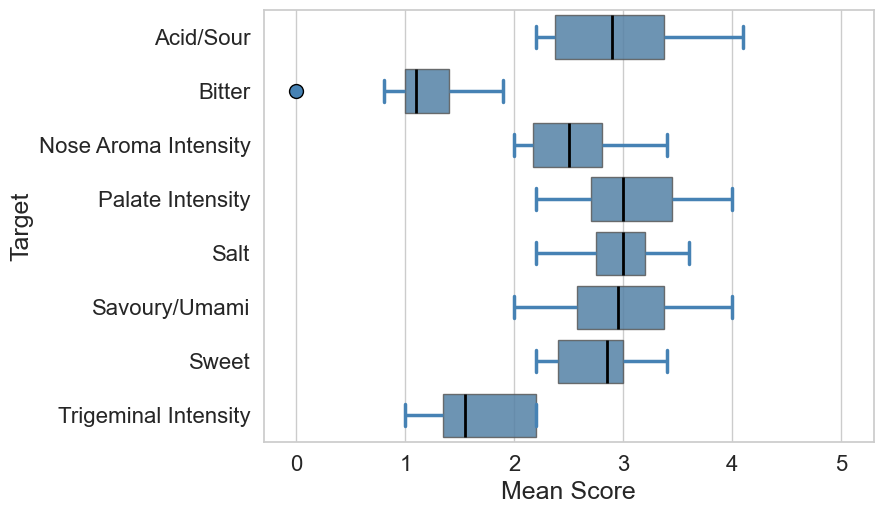

,mean,median,std,min,max,count,CV (%)
Target,,,,,,,
Acid/Sour,2.933333,2.90,0.624257,2.2,4.1,12.0,21.3
Bitter,1.141667,1.10,0.490748,0.0,1.9,12.0,43.0
Nose Aroma Intensity,2.516667,2.50,0.436585,2.0,3.4,12.0,17.3
Palate Intensity,3.045833,3.00,0.582104,2.2,4.0,12.0,19.1
Salt,2.983333,3.00,0.413045,2.2,3.6,12.0,13.8
Savoury/Umami,3.016667,2.95,0.614718,2.0,4.0,12.0,20.4
Sweet,2.758333,2.85,0.355370,2.2,3.4,12.0,12.9
Trigeminal Intensity,1.691667,1.55,0.473782,1.0,2.2,12.0,28.0


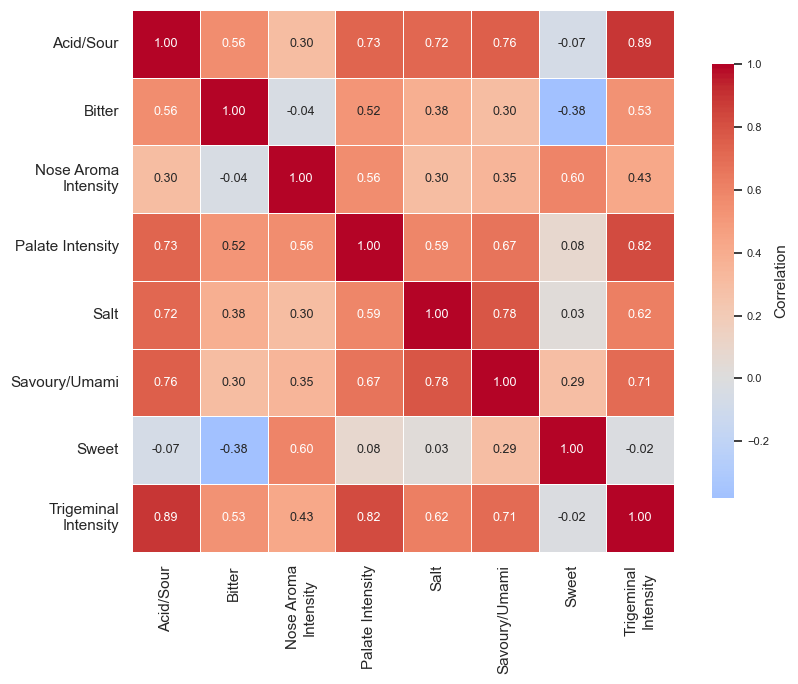

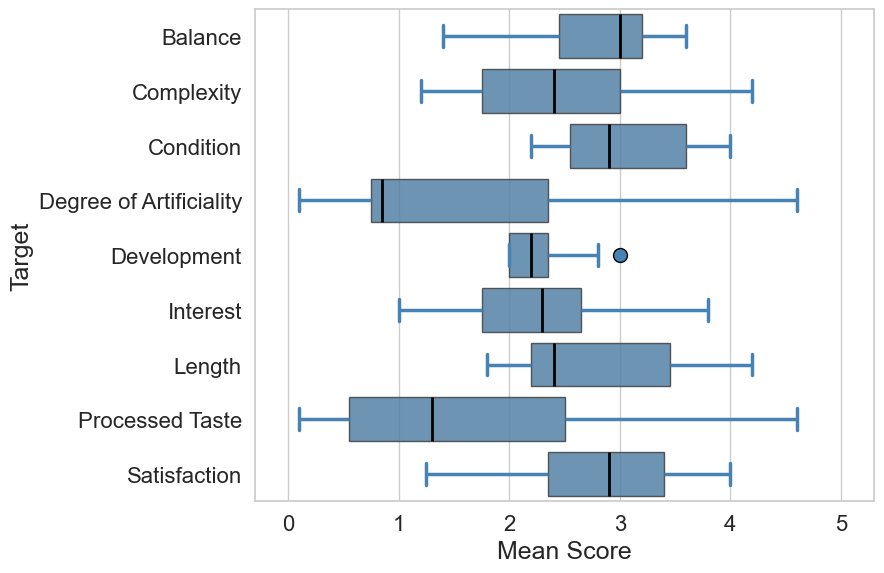

,mean,median,std,min,max,count,CV (%)
Target,,,,,,,
Balance,2.750000,3.00,0.693476,1.40,3.6,12.0,25.2
Complexity,2.433333,2.40,0.873169,1.20,4.2,12.0,35.9
Condition,3.016667,2.90,0.581273,2.20,4.0,12.0,19.3
Degree of Artificiality,1.666667,0.85,1.622755,0.10,4.6,12.0,97.4
Development,2.283333,2.20,0.366391,2.00,3.0,12.0,16.0
Interest,2.237500,2.30,0.779605,1.00,3.8,12.0,34.8
Length,2.800000,2.40,0.795442,1.80,4.2,12.0,28.4
Processed Taste,1.791667,1.30,1.664855,0.10,4.6,12.0,92.9
Satisfaction,2.787500,2.90,0.836694,1.25,4.0,12.0,30.0


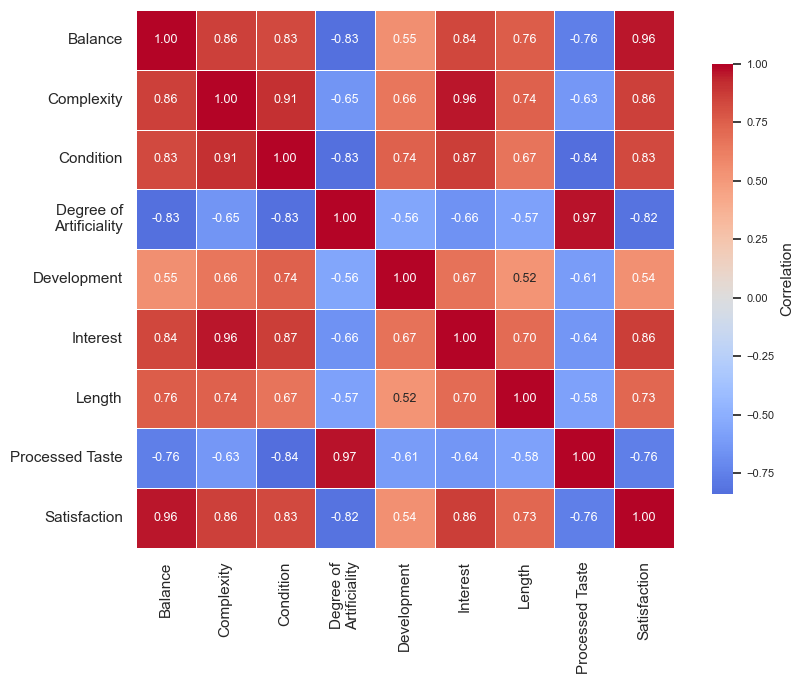

In [9]:
for Y in (Y_taste, Y_quality):
    fig, ax = plt.subplots(figsize=(9, 0.6 * Y.shape[1] + 0.5))
    sns.boxplot(data=Y[sorted(Y.columns)], orient="h", ax=ax, **BOX_STYLE)
    ax.set_xlim(-0.3, 5.3)
    ax.set_xlabel("Mean Score", fontsize=18)
    ax.set_ylabel("Target", fontsize=18)
    ax.tick_params(labelsize=16)
    plt.tight_layout()
    plt.show()

    stats = Y.agg(["mean", "median", "std", "min", "max", "count"]).T
    stats["CV (%)"] = (stats["std"] / stats["mean"] * 100).round(1)
    display(stats)

    correlation_heatmap(Y.corr(), figsize=(9, 7), fontsize=11)

## 3 Physical data

Replicate measurements are averaged in two steps: first per batch, then per trial.

In [10]:
physical_raw = pd.read_excel(PHYSICAL_PATH, sheet_name="Physical Data")
physical_raw["Trial"] = physical_raw["Trial"].astype(str)

physical_long = physical_raw[physical_raw["Trial"].isin(TRIALS + list(BATCHES_OF_240988))].copy()
physical_long["Batch"] = physical_long["Trial"].map(BATCHES_OF_240988).fillna(1).astype(int)
physical_long["Trial"] = physical_long["Trial"].replace(dict.fromkeys(BATCHES_OF_240988, "240988"))
physical_long["Parameter"] = physical_long["Parameter"].map(PHYSICAL_PARAMETERS)
physical_long = physical_long.dropna(subset=["Parameter"])

physical = (
    physical_long.groupby(["Trial", "Batch", "Parameter"])["Value"].mean()
    .groupby(["Trial", "Parameter"]).mean()
    .unstack()[list(PHYSICAL_PARAMETERS.values())]
)
print(f"Physical features: {physical.shape}  (trials x features)")

Physical features: (12, 20)  (trials x features)


,Parameters,Rows
Analysis,,
Fat and Moisture,"fat, moisture",96
Oven,"melting, oiling",104
Rheometer,"average extensibility, average viscosity, complex viscosity, glass transition temperature, max extensibility, max viscosity, melted adhesiveness, melting speed, min viscosity",450
Texturometer,"adhesiveness, chewiness, cohesiveness, gumminess, hardness, resilience, springiness",1218


,count,mean,std,min,25%,50%,75%,max
Parameter,,,,,,,,
adhesiveness,174.0,-19.115,23.652,-91.33,-35.585,-5.665,-1.022,0.00
average extensibility,50.0,0.192,0.224,0.00,0.022,0.085,0.300,0.78
average viscosity,50.0,435820.000,401753.417,75400.00,94800.000,323000.000,620500.000,1600000.00
chewiness,174.0,10710.320,6898.949,526.01,5750.938,9439.145,13324.928,36666.25
cohesiveness,174.0,12.422,5.111,1.41,8.180,13.420,16.378,28.26
complex viscosity,50.0,1028.544,572.922,330.58,634.808,785.530,1424.125,2645.60
fat,48.0,29.403,5.499,0.00,27.388,31.595,32.662,33.66
glass transition temperature,50.0,66.576,5.258,58.50,62.225,65.000,72.050,75.30
gumminess,174.0,83422.047,40898.778,7629.16,56241.402,80380.120,102490.752,191971.56


Parameter,adhesiveness,average extensibility,average viscosity,chewiness,cohesiveness,complex viscosity,fat,glass transition temperature,gumminess,hardness,max extensibility,max viscosity,melted adhesiveness,melting,melting speed,min viscosity,moisture,oiling,resilience,springiness,Total
Trial,,,,,,,,,,,,,,,,,,,,,
110001,48,5,5,48,48,5,3,5,48,48,5,5,5,9,5,5,3,6,48,48,402
110002,7,3,3,7,7,3,3,3,7,7,3,3,3,3,3,3,3,3,7,7,88
110009,19,6,6,19,19,6,6,6,19,19,6,6,6,6,6,6,6,6,19,19,211
110019,9,3,3,9,9,3,3,3,9,9,3,3,3,3,3,3,3,3,9,9,102
110020,9,3,3,9,9,3,3,3,9,9,3,3,3,3,3,3,3,3,9,9,102
110021,8,3,3,8,8,3,3,3,8,8,3,3,3,3,3,3,3,3,8,8,95
110022,9,3,3,9,9,3,3,3,9,9,3,3,3,3,3,3,3,3,9,9,102
110023,9,3,3,9,9,3,3,3,9,9,3,3,3,3,3,3,3,3,9,9,102
110024,9,3,3,9,9,3,3,3,9,9,3,3,3,3,3,3,3,3,9,9,102


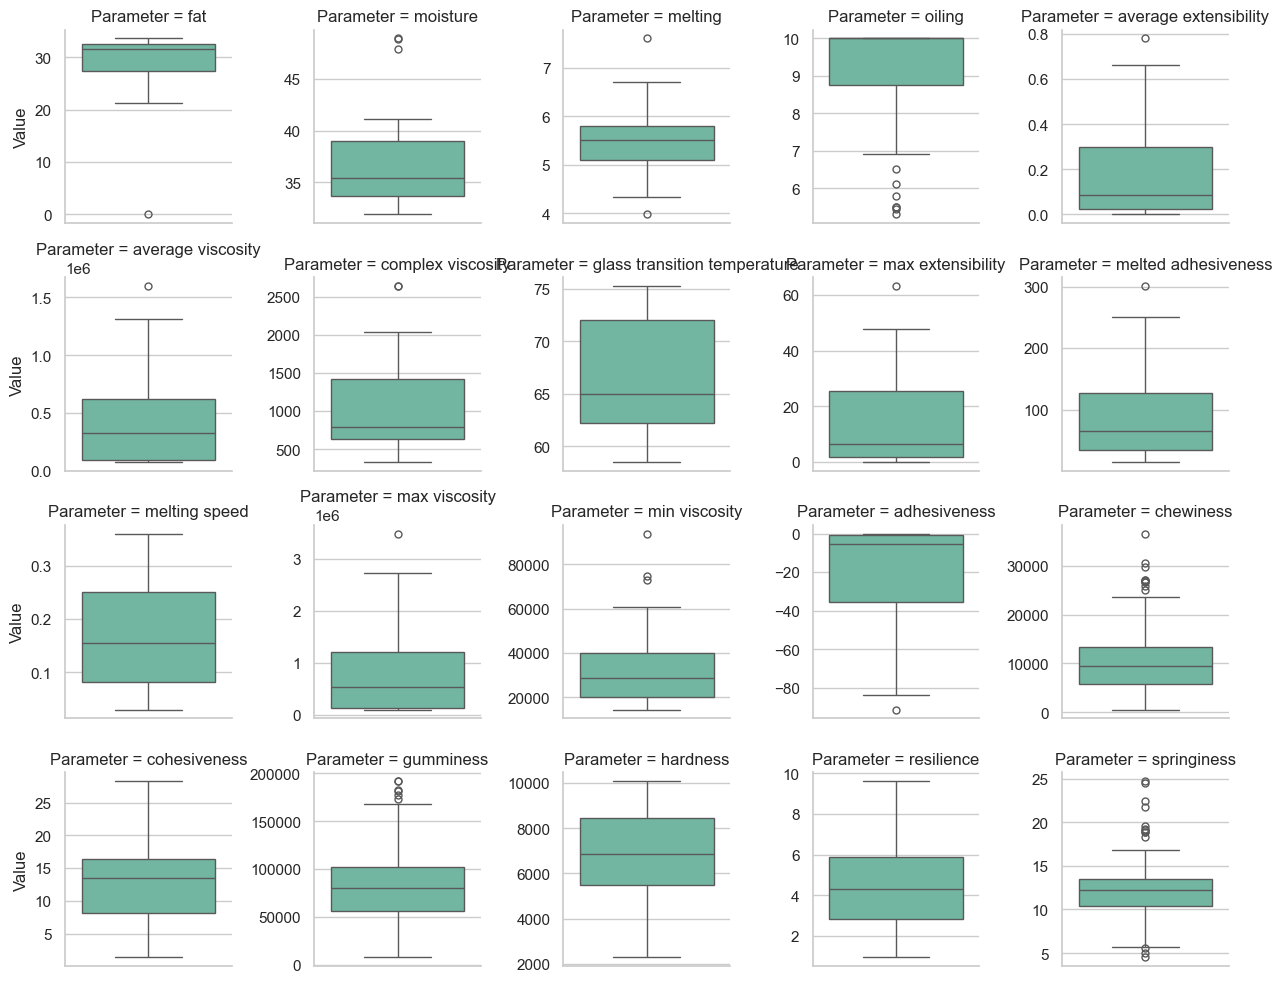

In [11]:
# Parameters per instrument and number of replicate measurements per trial and parameter
display(physical_long.groupby("Analysis")["Parameter"]
        .agg(Parameters=lambda p: ", ".join(sorted(p.unique())), Rows="count"))
display(physical_long.groupby("Parameter")["Value"].describe().round(3))

replicates = physical_long.groupby(["Trial", "Parameter"]).size().unstack()
replicates["Total"] = replicates.sum(axis=1)
display(replicates)

# Replicate values before averaging
sns.catplot(data=physical_long, y="Value", col="Parameter", col_wrap=5, kind="box",
            sharey=False, height=2.5)
plt.show()

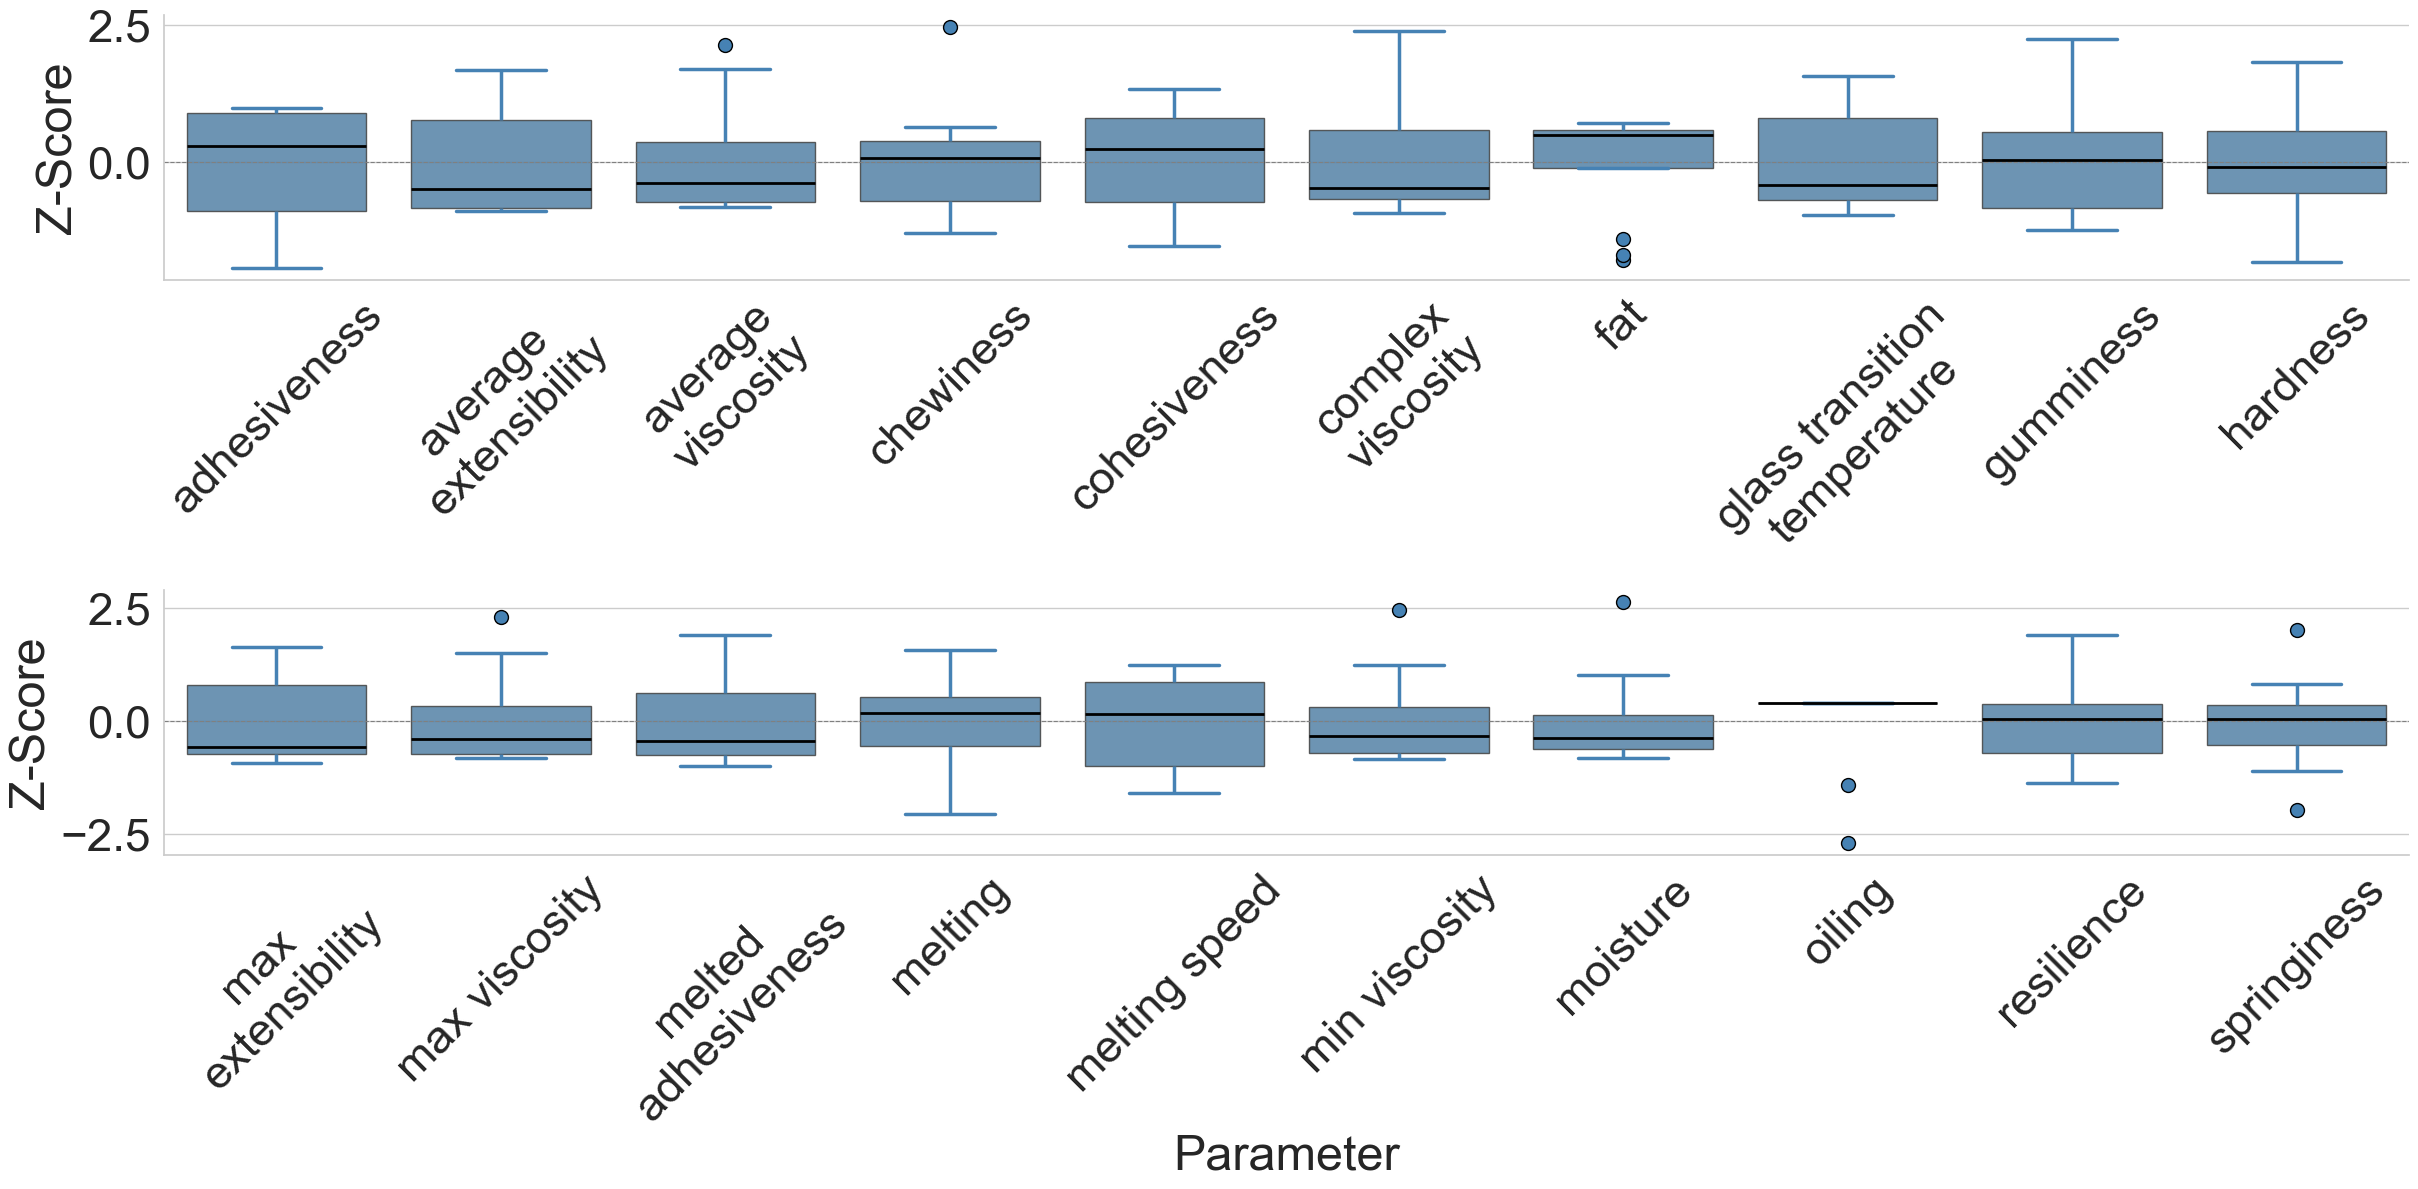

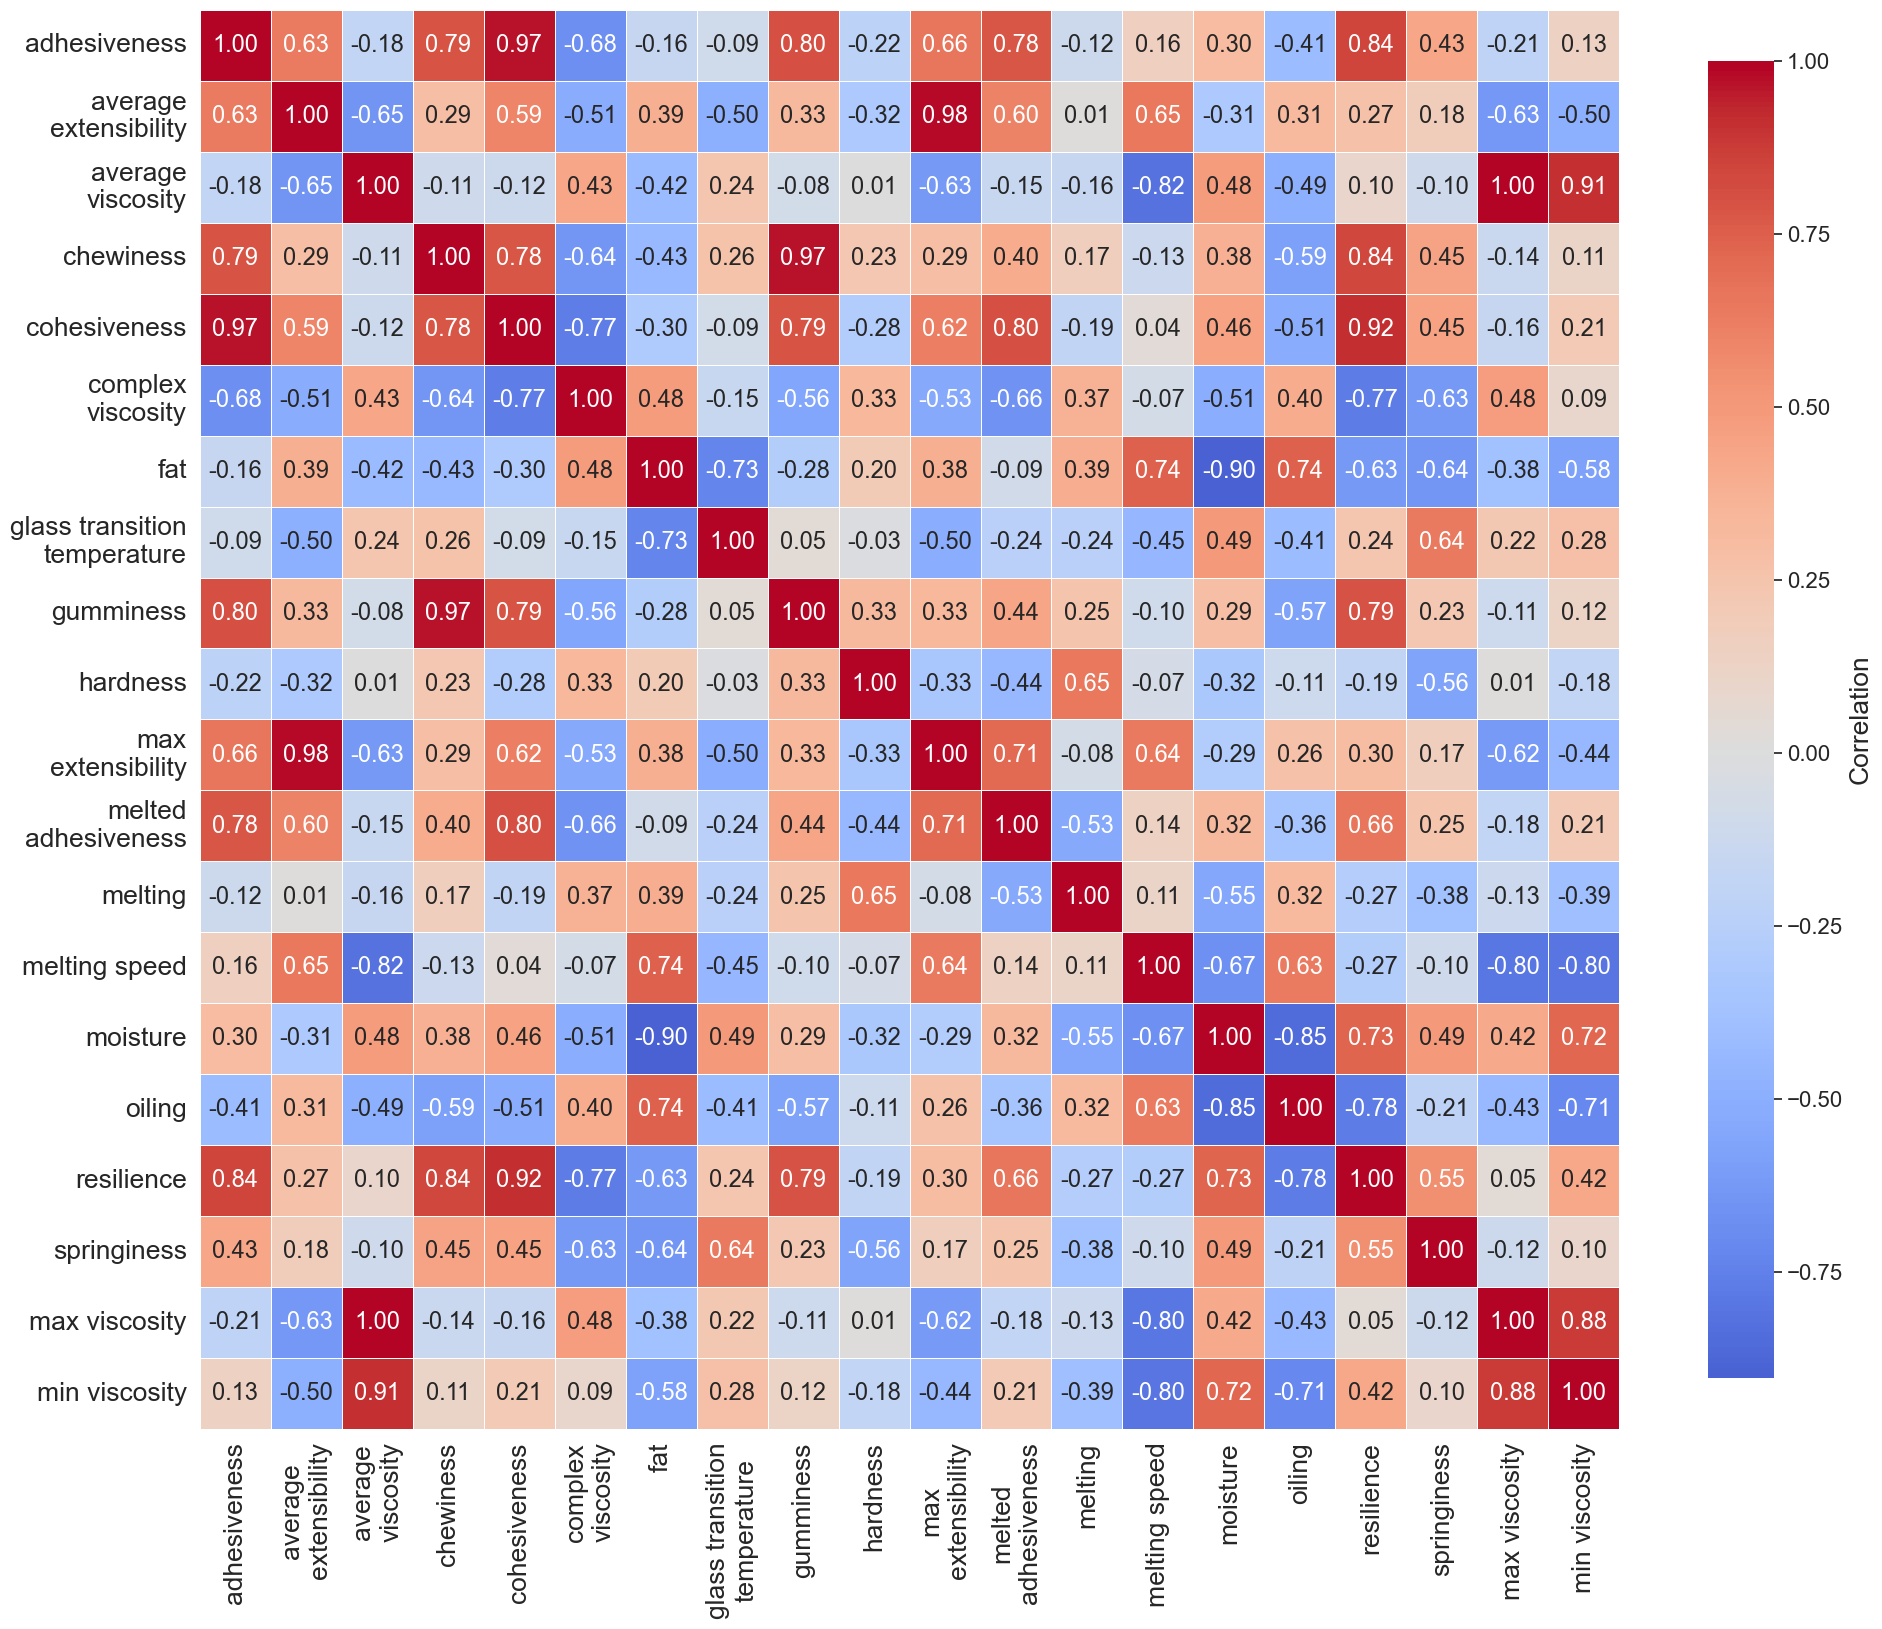

In [56]:
z_boxplot(physical[sorted(physical.columns)], "Parameter", figsize=(24, 12), fontsize=35, rows=2)
correlation_heatmap(physical.corr(), figsize=(20, 18), fontsize=19)

## 4 E-tongue data

Each trial was measured in three cycles, which are averaged.

In [13]:
etongue_raw = pd.read_excel(ETONGUE_PATH).rename(columns={"Sample": "Trial", **ETONGUE_SENSORS})
etongue_raw["Trial"] = etongue_raw["Trial"].astype(str)
etongue_raw = etongue_raw[etongue_raw["Trial"].isin(TRIALS)].set_index(["Trial", "Number of Cycle"])
etongue_raw = etongue_raw.apply(pd.to_numeric, errors="coerce")

print("Mean sensor values per measurement cycle:")
display(etongue_raw.groupby("Number of Cycle").mean().round(3))

etongue = etongue_raw.groupby("Trial").mean()
print(f"E-tongue features: {etongue.shape}")
display(etongue.describe().T)

Mean sensor values per measurement cycle:


,sour,bitter,astringent,umami,salty,bitter aftertaste,astringent aftertaste,umami aftertaste
Number of Cycle,,,,,,,,
2,11.539,5.273,0.722,-0.999,0.376,1.243,0.268,4.757
3,11.388,5.272,0.778,-0.856,0.352,1.278,0.298,4.688
4,11.135,5.244,0.768,-0.720,0.358,1.281,0.292,4.658


E-tongue features: (12, 8)


,count,mean,std,min,25%,50%,75%,max
sour,12.0,11.354167,1.066006,8.816667,11.142500,11.683333,12.010833,12.556667
bitter,12.0,5.263333,1.239712,2.630000,4.848333,5.203333,5.813333,7.823333
astringent,12.0,0.756111,0.466134,0.110000,0.533333,0.673333,0.844167,1.806667
umami,12.0,-0.858333,1.509498,-4.633333,-0.860833,-0.241667,-0.034167,0.423333
salty,12.0,0.361944,0.881067,-1.690000,0.005833,0.361667,0.889167,1.640000
bitter aftertaste,12.0,1.267222,0.649113,0.423333,1.033333,1.105000,1.199167,3.040000
astringent aftertaste,12.0,0.285833,0.108908,0.100000,0.231667,0.305000,0.330000,0.496667
umami aftertaste,12.0,4.701111,1.701367,1.020000,4.907500,5.533333,5.624167,5.860000


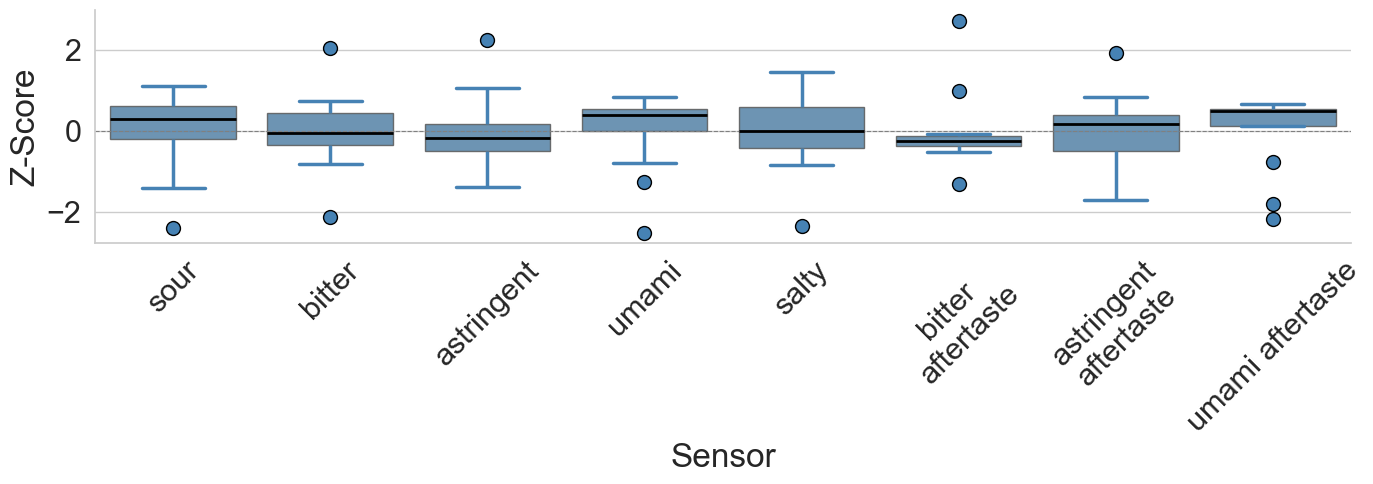

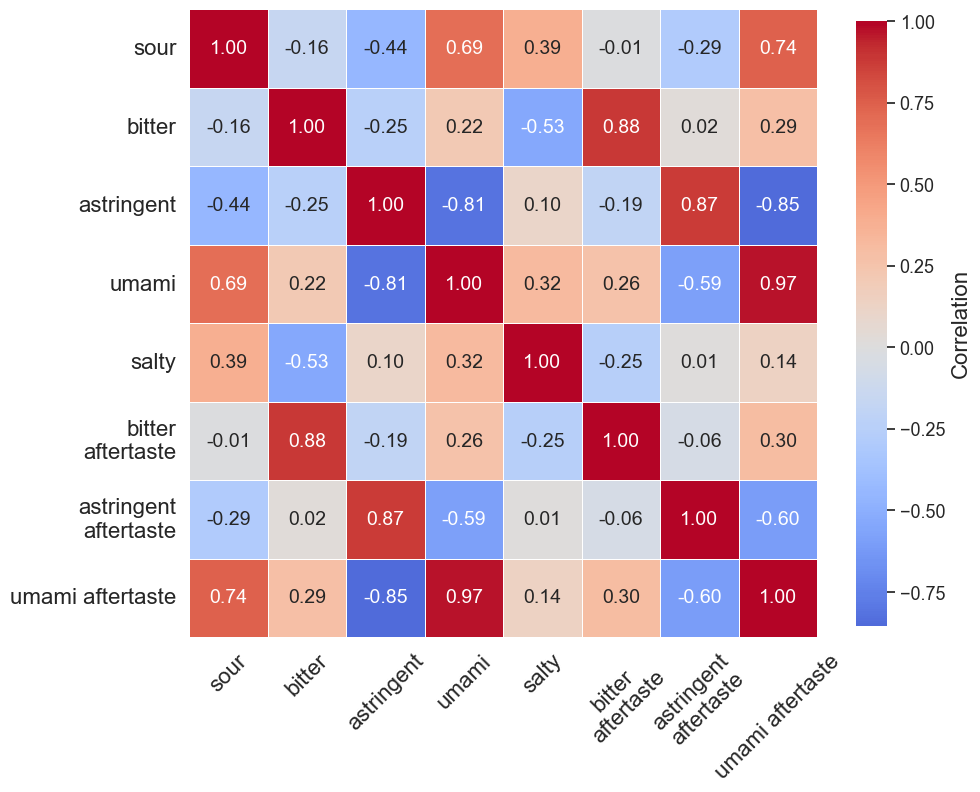

In [57]:
z_boxplot(etongue, "Sensor", figsize=(14, 5), fontsize=24)
correlation_heatmap(etongue.corr(), figsize=(10, 9), fontsize=16, rotation=45)

## 5 GC-MS data

Two representations of the GC-MS data are built:

1. **Compounds**: log-transformed peak area per compound, restricted to compounds
   detected in at least six trials.
2. **Odour groups** (Flavour Tree): log-transformed peak area multiplied by the odour
   intensity, summed per odour group of the Academy of Cheese Flavour Tree.

In [15]:
# One sheet per trial; the last two columns (three for trial 110019) are not part of the table
sheets = pd.read_excel(GCMS_PATH, sheet_name=None)
gcms_raw = pd.concat(
    [sheet.iloc[:, :-3] if name == "110019" else sheet.iloc[:, :-2] for name, sheet in sheets.items()],
    ignore_index=True,
)
gcms_raw["Trial"] = gcms_raw["Trial"].astype(str)
print(f"GC-MS rows (all detected peaks, all trials): {len(gcms_raw)}")

# Keep identified compounds with an odour description ("?" marks a missing description)
gcms = gcms_raw[gcms_raw["Formula"].notna() & gcms_raw["Odour"].notna()
                & (gcms_raw["Odour"] != "?")].copy()
gcms["Name"] = gcms["Name"].replace(COMPOUND_SYNONYMS)
# Identifier of a compound: name and molecular formula
gcms["Compound_Key"] = (gcms["Name"].astype(str).str.strip().str.replace(",", "_", regex=False)
                        + "__" + gcms["Formula"].astype(str).str.strip())
gcms["Area_log10"] = np.log10(gcms["Area"].fillna(0) + 1)
print(f"Peaks with an odour description: {len(gcms)} | compounds: {gcms['Compound_Key'].nunique()}")
print("Compounds per trial:")
display(gcms.groupby("Trial")["Compound_Key"].nunique().to_frame("Compounds").T)

GC-MS rows (all detected peaks, all trials): 923
Peaks with an odour description: 151 | compounds: 48
Compounds per trial:


Trial,110001,110002,110009,110019,110020,110021,110022,110023,110024,120003,120004,240988
Compounds,11,9,10,14,19,16,6,5,15,15,14,16


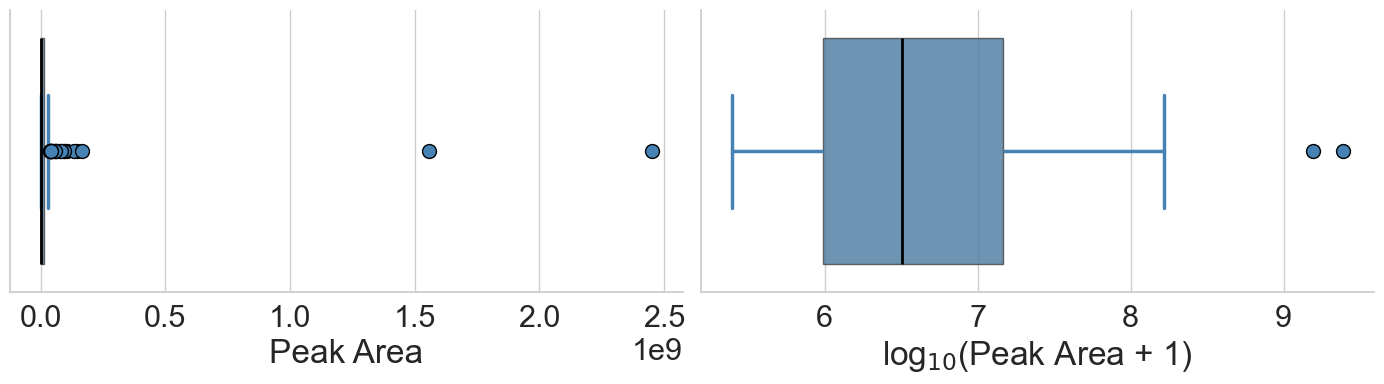

In [16]:
# Peak area before and after the log transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, column, xlabel in zip(axes, ["Area", "Area_log10"], ["Peak Area", "log$_{10}$(Peak Area + 1)"]):
    sns.boxplot(x=gcms[column], ax=ax, **BOX_STYLE)
    ax.set_xlabel(xlabel, fontsize=24)
    ax.tick_params(labelsize=22)
    ax.xaxis.get_offset_text().set_fontsize(22)
sns.despine()
plt.tight_layout()
plt.show()

### 5.1 Compounds

Compounds kept: 9 of 48 (detected in at least 6 trials)


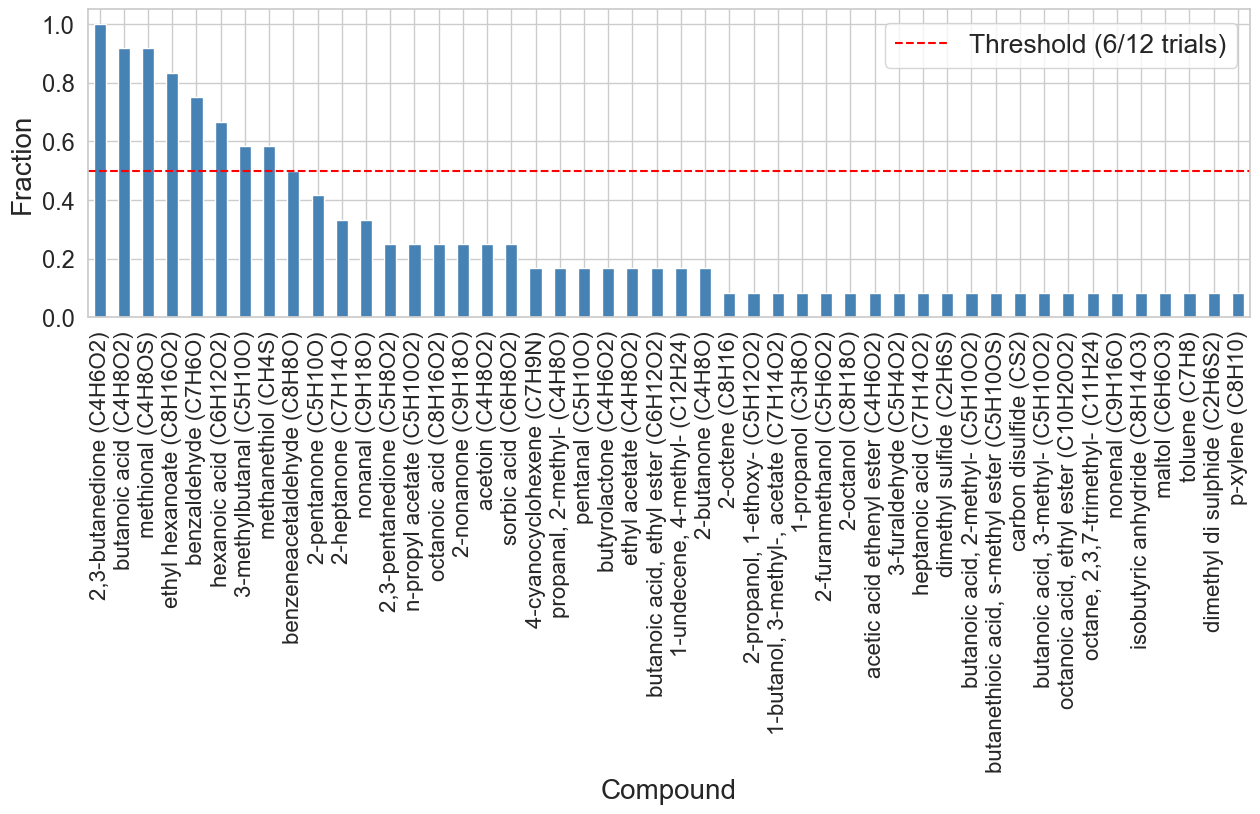

In [17]:
def compound_name(key):
    """Feature name of a compound: lower-case name followed by the molecular formula."""
    name, formula = key.rsplit("__", 1)
    name = name.replace("_", ",").lower()
    return f"{COMPOUND_NAMES.get(name, name)} ({formula})"


# Trial x compound matrix (peaks of the same compound within a trial are summed)
compounds_all = (
    gcms.pivot_table(index="Trial", columns="Compound_Key", values="Area_log10", aggfunc="sum")
    .fillna(0)
    .rename(columns=compound_name)
)
detected_in = (compounds_all > 0).sum()
compounds = compounds_all.loc[:, detected_in >= GCMS_MIN_TRIALS]
print(f"Compounds kept: {compounds.shape[1]} of {compounds_all.shape[1]} "
      f"(detected in at least {GCMS_MIN_TRIALS} trials)")

# Detection frequency of all compounds
frequency = (detected_in / len(compounds_all)).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(15, 4))
frequency.plot(kind="bar", color="steelblue", edgecolor="white", ax=ax)
ax.axhline(GCMS_MIN_TRIALS / len(compounds_all), color="red", linestyle="--",
           label=f"Threshold ({GCMS_MIN_TRIALS}/{len(compounds_all)} trials)")
ax.set_xlabel("Compound", fontsize=20)
ax.set_ylabel("Fraction", fontsize=20)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=17)
ax.legend(fontsize=19)
plt.show()

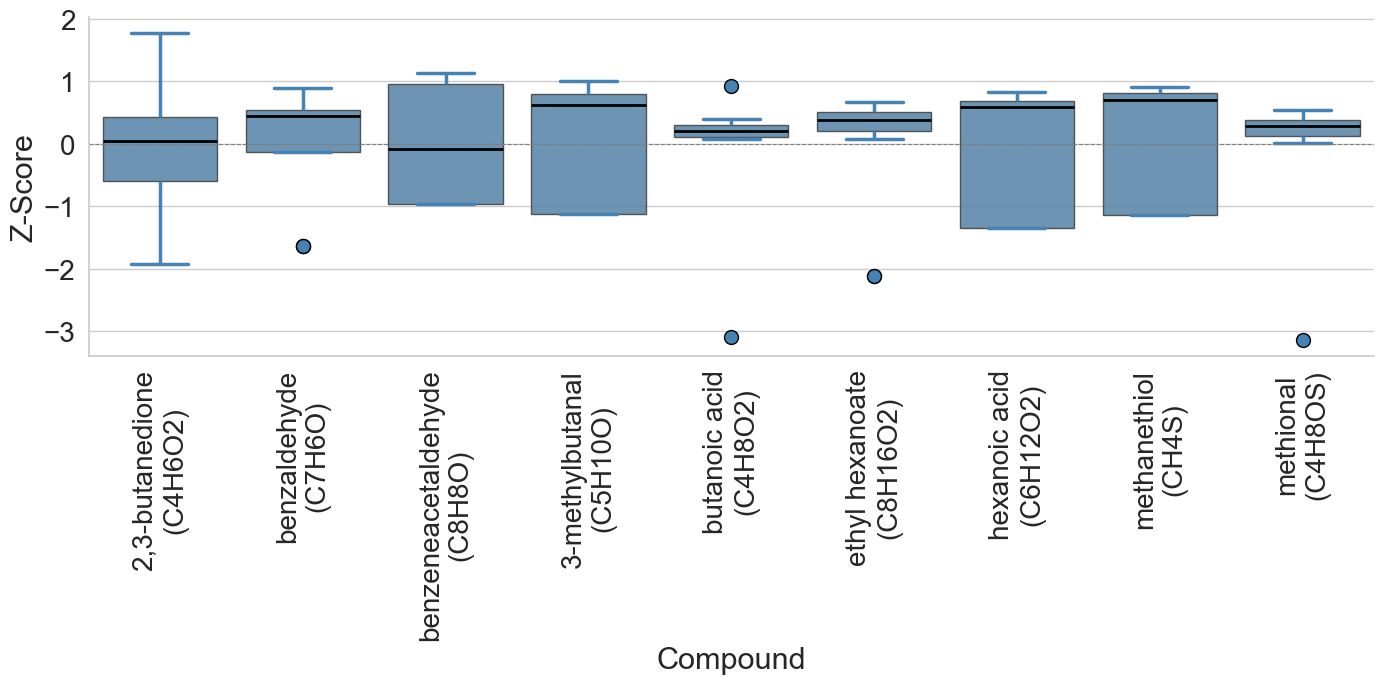

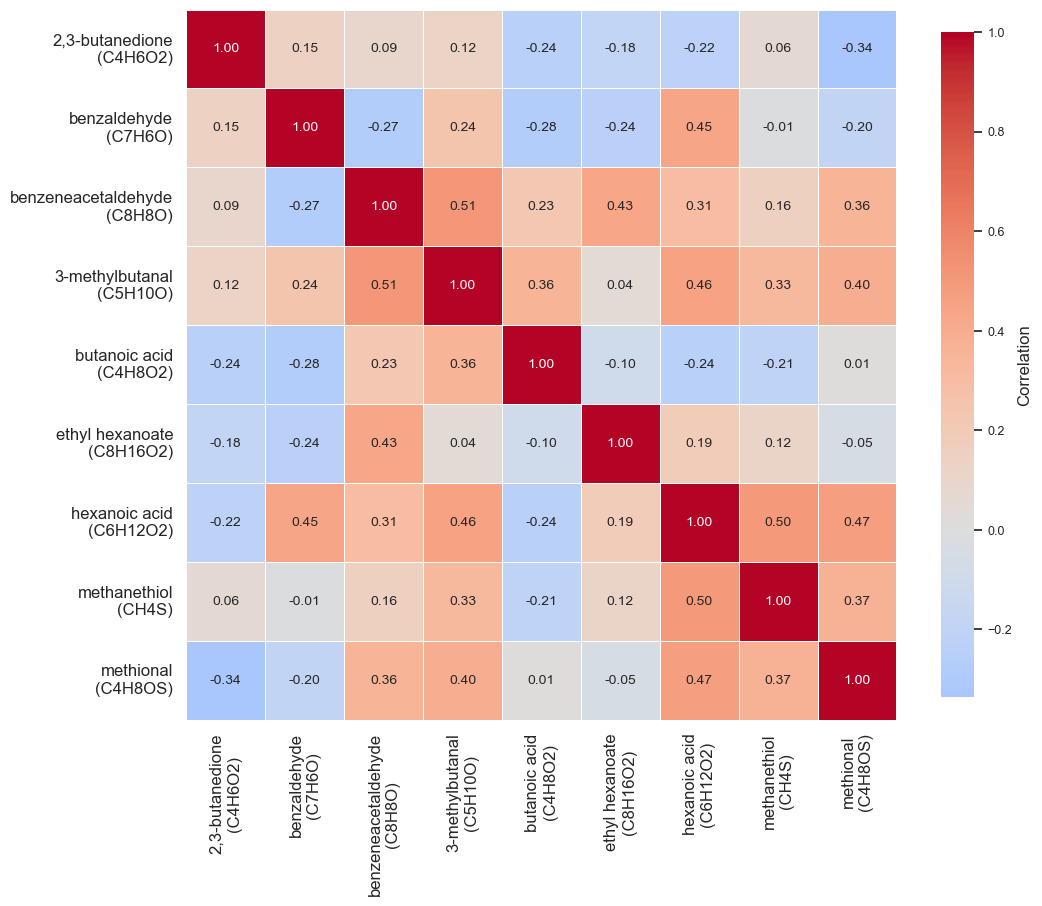

In [58]:
z_boxplot(compounds, "Compound", figsize=(14, 7), fontsize=22, rotation=90)
correlation_heatmap(compounds.corr(), figsize=(11, 10), fontsize=12)

### 5.2 Odour groups (Flavour Tree)

In [19]:
# Odour descriptor -> odour group, read from the Flavour Tree
tree = pd.read_excel(FLAVOUR_TREE_PATH).iloc[1:].copy()
tree["1st Degree (Simple)"] = tree["1st Degree (Simple)"].ffill()
odour_columns = [c for c in tree.columns if str(c).startswith("SPME GC-MS Odour")]
odour_to_group = {}
for _, row in tree.iterrows():
    for column in odour_columns:
        descriptor = str(row[column]).strip()
        if pd.notna(row[column]) and descriptor not in ("", "nan"):
            odour_to_group[descriptor] = row["1st Degree (Simple)"]

gcms["Odour_Group"] = (gcms["Odour"].astype(str).str.strip().map(odour_to_group)
                       .fillna("other/unknown").str.lower())
for group, rows in MANUAL_ODOUR_GROUPS.items():
    gcms.loc[gcms.index.isin(rows), "Odour_Group"] = group
# The E-tongue has a sensor of the same name, so the odour group gets a distinct feature name
gcms["Odour_Group"] = gcms["Odour_Group"].replace({"salty": "salty (odour)"})

flavour = gcms[~gcms["Odour_Group"].isin(EXCLUDED_ODOUR_GROUPS)].copy()
flavour["Weighted_Signal"] = flavour["Area_log10"] * flavour["Intensity"].fillna(0)
odour_groups = flavour.groupby(["Trial", "Odour_Group"])["Weighted_Signal"].sum().unstack(fill_value=0)

print(f"Odour groups: {odour_groups.shape[1]}")
print("Compounds per odour group:")
display(flavour.groupby("Odour_Group")["Compound_Key"].nunique()
        .sort_values(ascending=False).to_frame("Compounds"))
n_groups = flavour.groupby("Compound_Key")["Odour_Group"].nunique()
print(f"Compounds assigned to more than one odour group: {(n_groups > 1).sum()}")

Odour groups: 9
Compounds per odour group:


,Compounds
Odour_Group,
mineral/chemical,15
sweet,11
dairy,8
fruity/floral,6
animal/fungal/fermented,5
vegetable leaf/herbaceous,5
acid,3
other/unknown,3
salty (odour),2


Compounds assigned to more than one odour group: 10


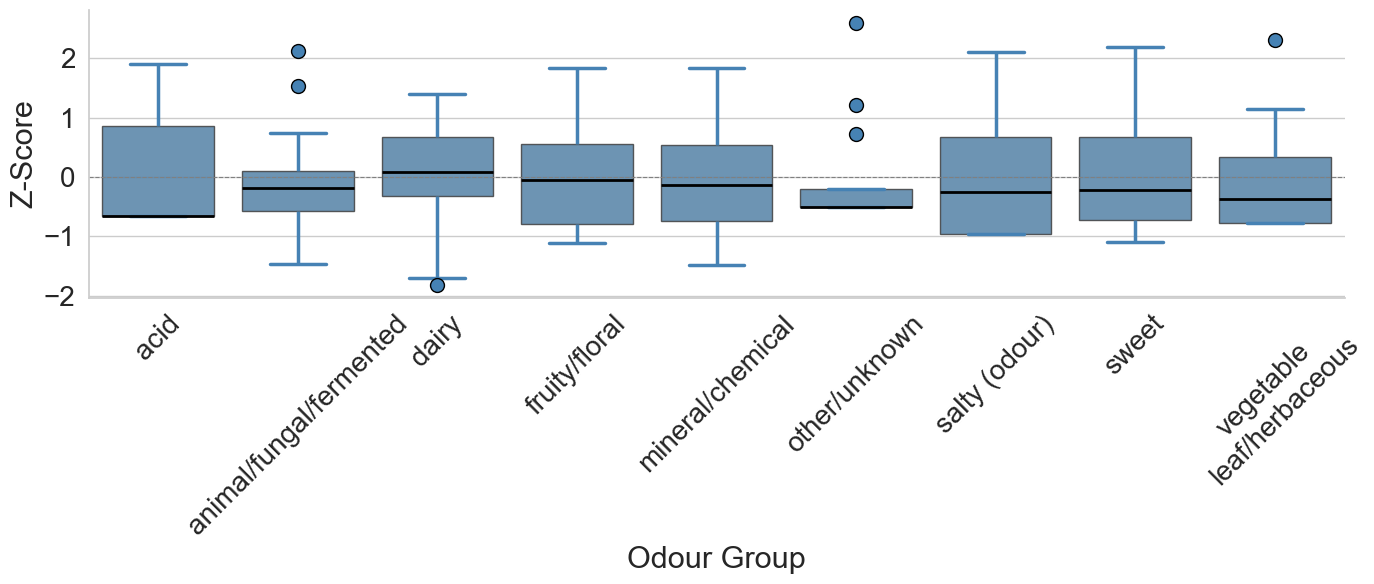

In [59]:
z_boxplot(odour_groups, "Odour Group", figsize=(14, 6), fontsize=22)

## 6 Tribology data

One value per trial and parameter, measured under dry and wet (artificial saliva) conditions.

In [21]:
tribology = pd.read_excel(TRIBOLOGY_PATH, sheet_name="Sheet1", header=1)
tribology = tribology.rename(columns={"Sample": "Trial", **TRIBOLOGY_PARAMETERS})
tribology["Trial"] = tribology["Trial"].astype(str).replace({"NFI": "240988"})  # NFI is trial 240988
tribology = tribology[tribology["Trial"].isin(TRIALS)].set_index("Trial")
tribology = tribology.apply(pd.to_numeric, errors="coerce")
print(f"Tribology features: {tribology.shape}")
display(tribology.describe().T)

Tribology features: (12, 16)


,count,mean,std,min,25%,50%,75%,max
width (dry),12.0,2267.416667,682.921992,1021.000000,2031.000000,2392.500000,2765.000000,3129.000000
depth (dry),12.0,77.327333,47.836790,0.000000,42.467000,94.691000,105.595000,166.400000
volume (dry),12.0,5.584839,4.334092,0.000000,1.326309,5.747412,7.705279,14.521728
wear scar roughness (dry),12.0,19.847917,12.407126,7.172000,10.944250,13.414000,25.427000,43.144000
roughness as cut (dry),12.0,20.850750,22.745184,5.772000,10.750500,15.127500,19.448250,91.146000
COF (dry),12.0,0.397973,0.085201,0.292791,0.329097,0.394428,0.452719,0.530210
COF forward (dry),12.0,0.404019,0.169298,0.205285,0.257921,0.386541,0.522424,0.754342
COF backward (dry),12.0,0.383950,0.099874,0.224143,0.293949,0.391778,0.458366,0.531089
width (wet),12.0,4056.500000,1158.439350,2461.000000,3394.750000,3884.000000,4486.500000,6879.000000
depth (wet),12.0,170.941167,137.094145,-92.600000,63.600000,188.577500,214.200000,410.800000


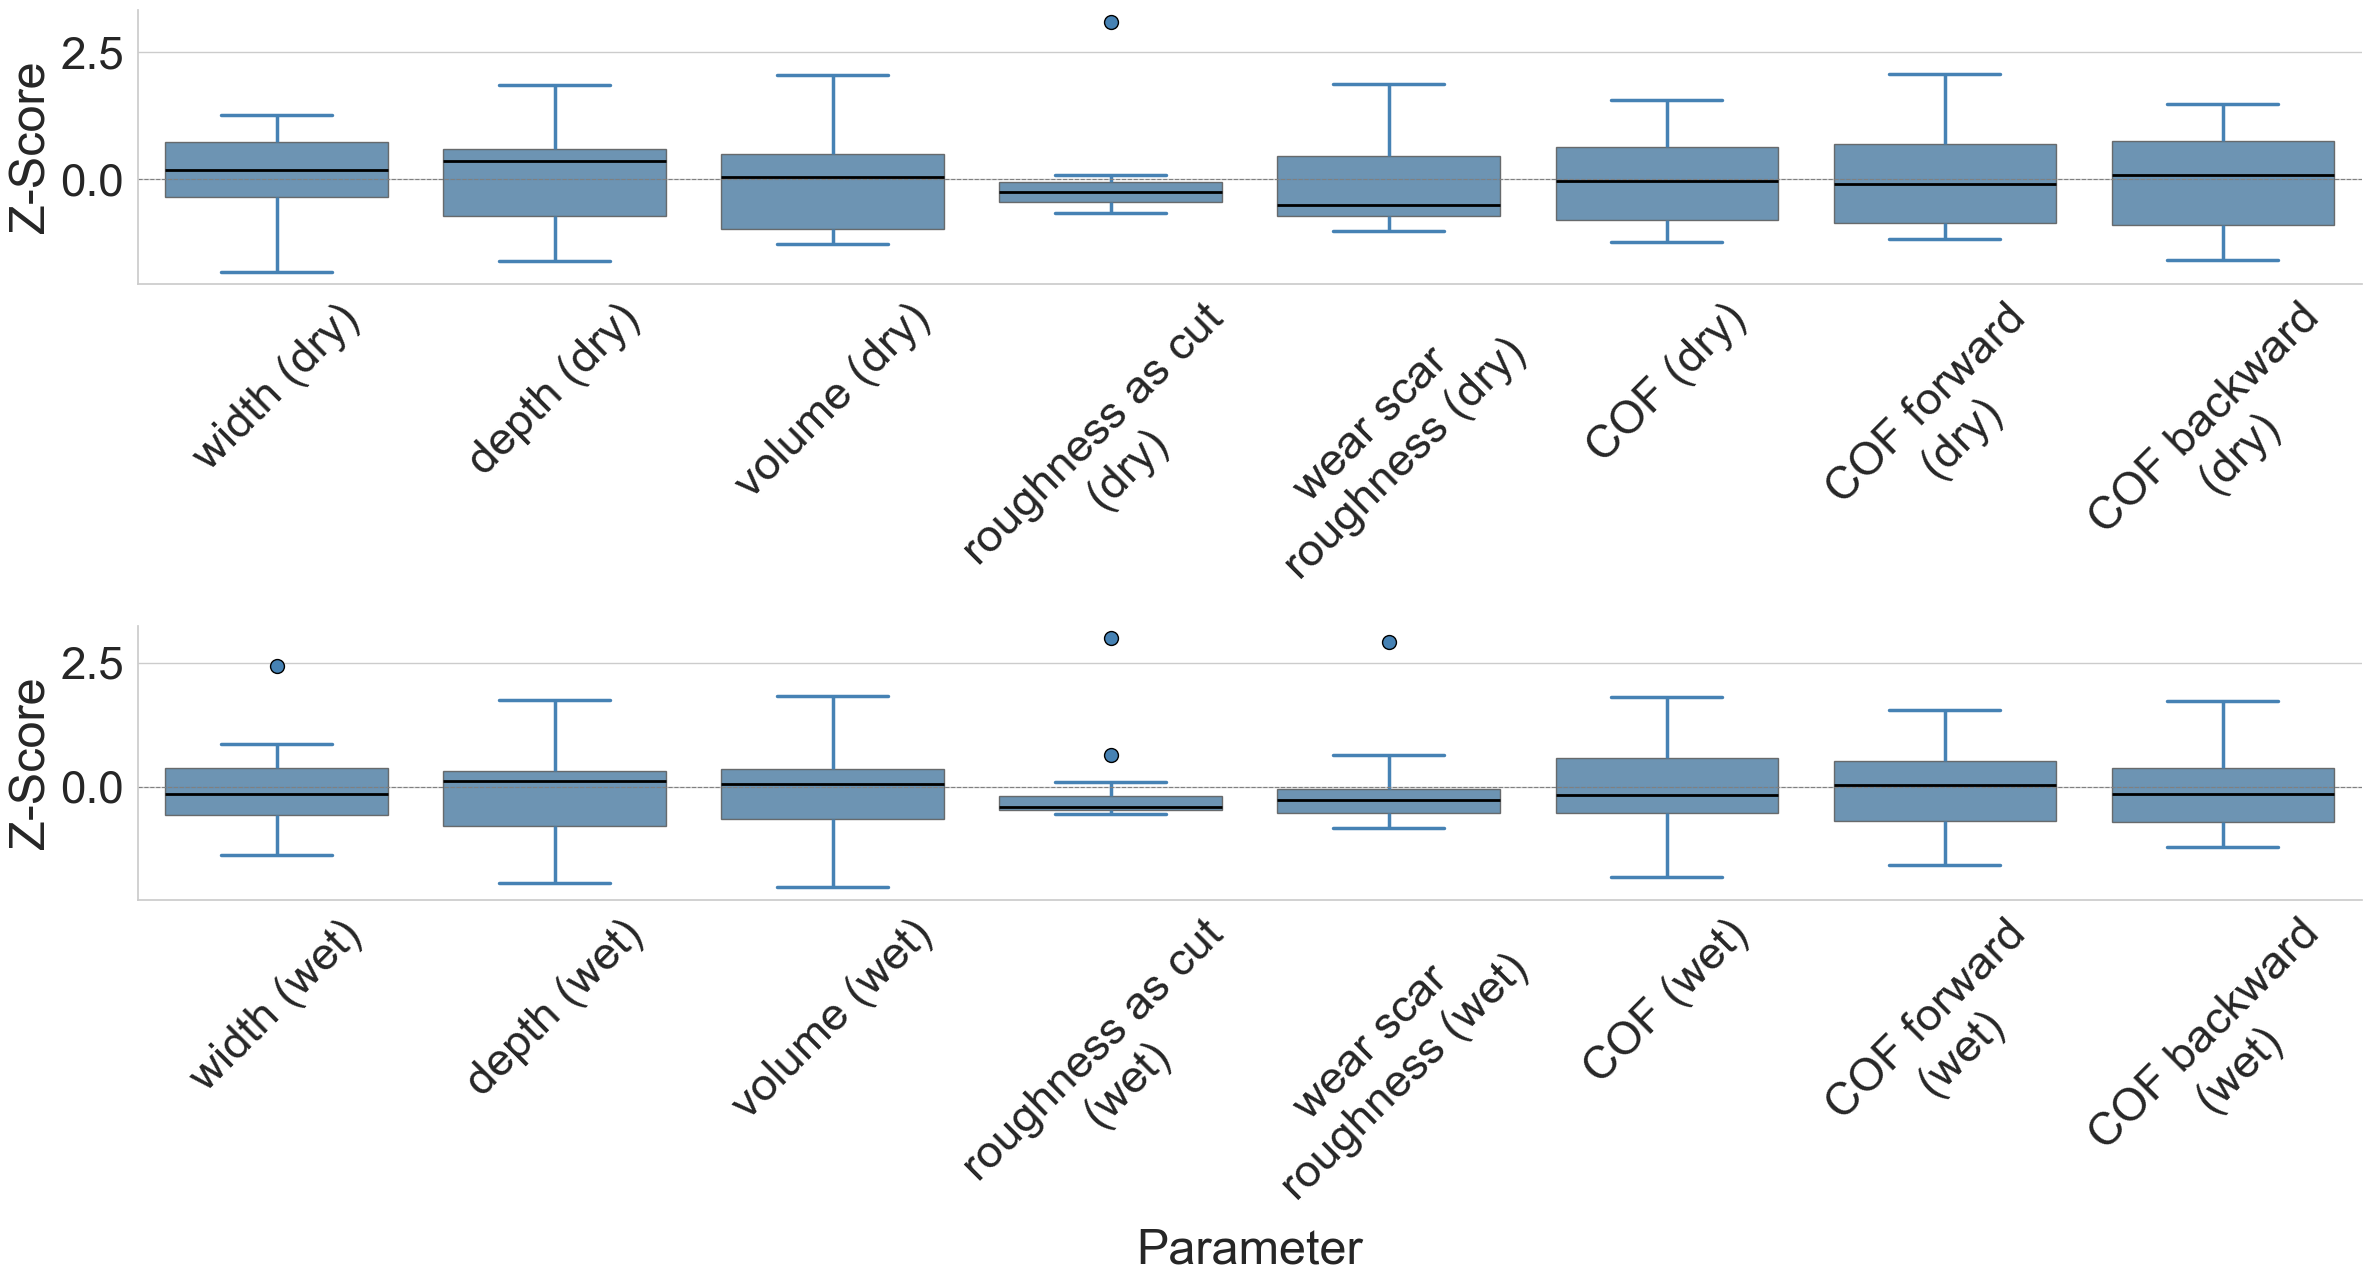

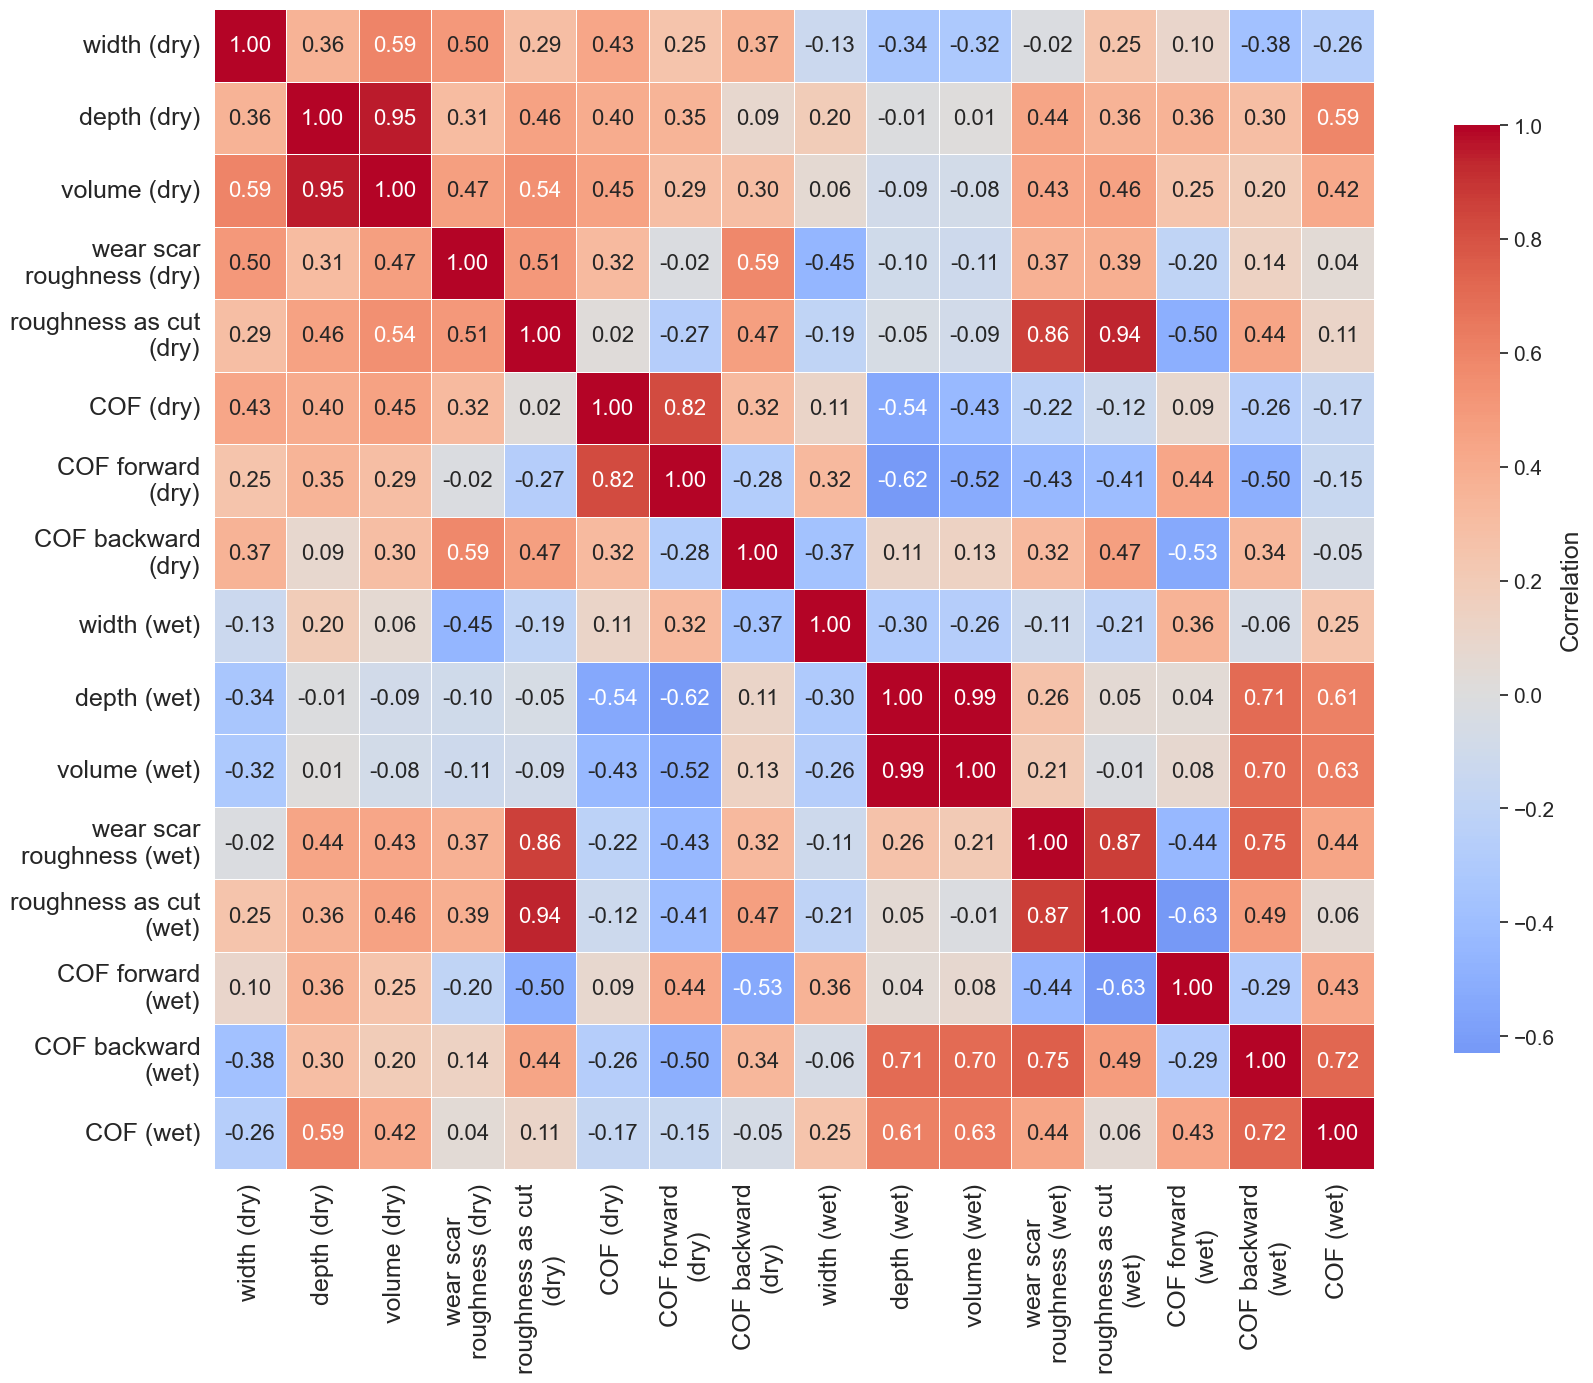

In [60]:
z_boxplot(tribology[list(TRIBOLOGY_PARAMETERS.values())], "Parameter",
          figsize=(24, 13), fontsize=35, rows=2)
correlation_heatmap(tribology.corr(), figsize=(18, 14), fontsize=18)

## 7 Feature-target correlations

Pearson correlations between every instrumental feature and every sensory target,
as a first indication of which modalities are informative.

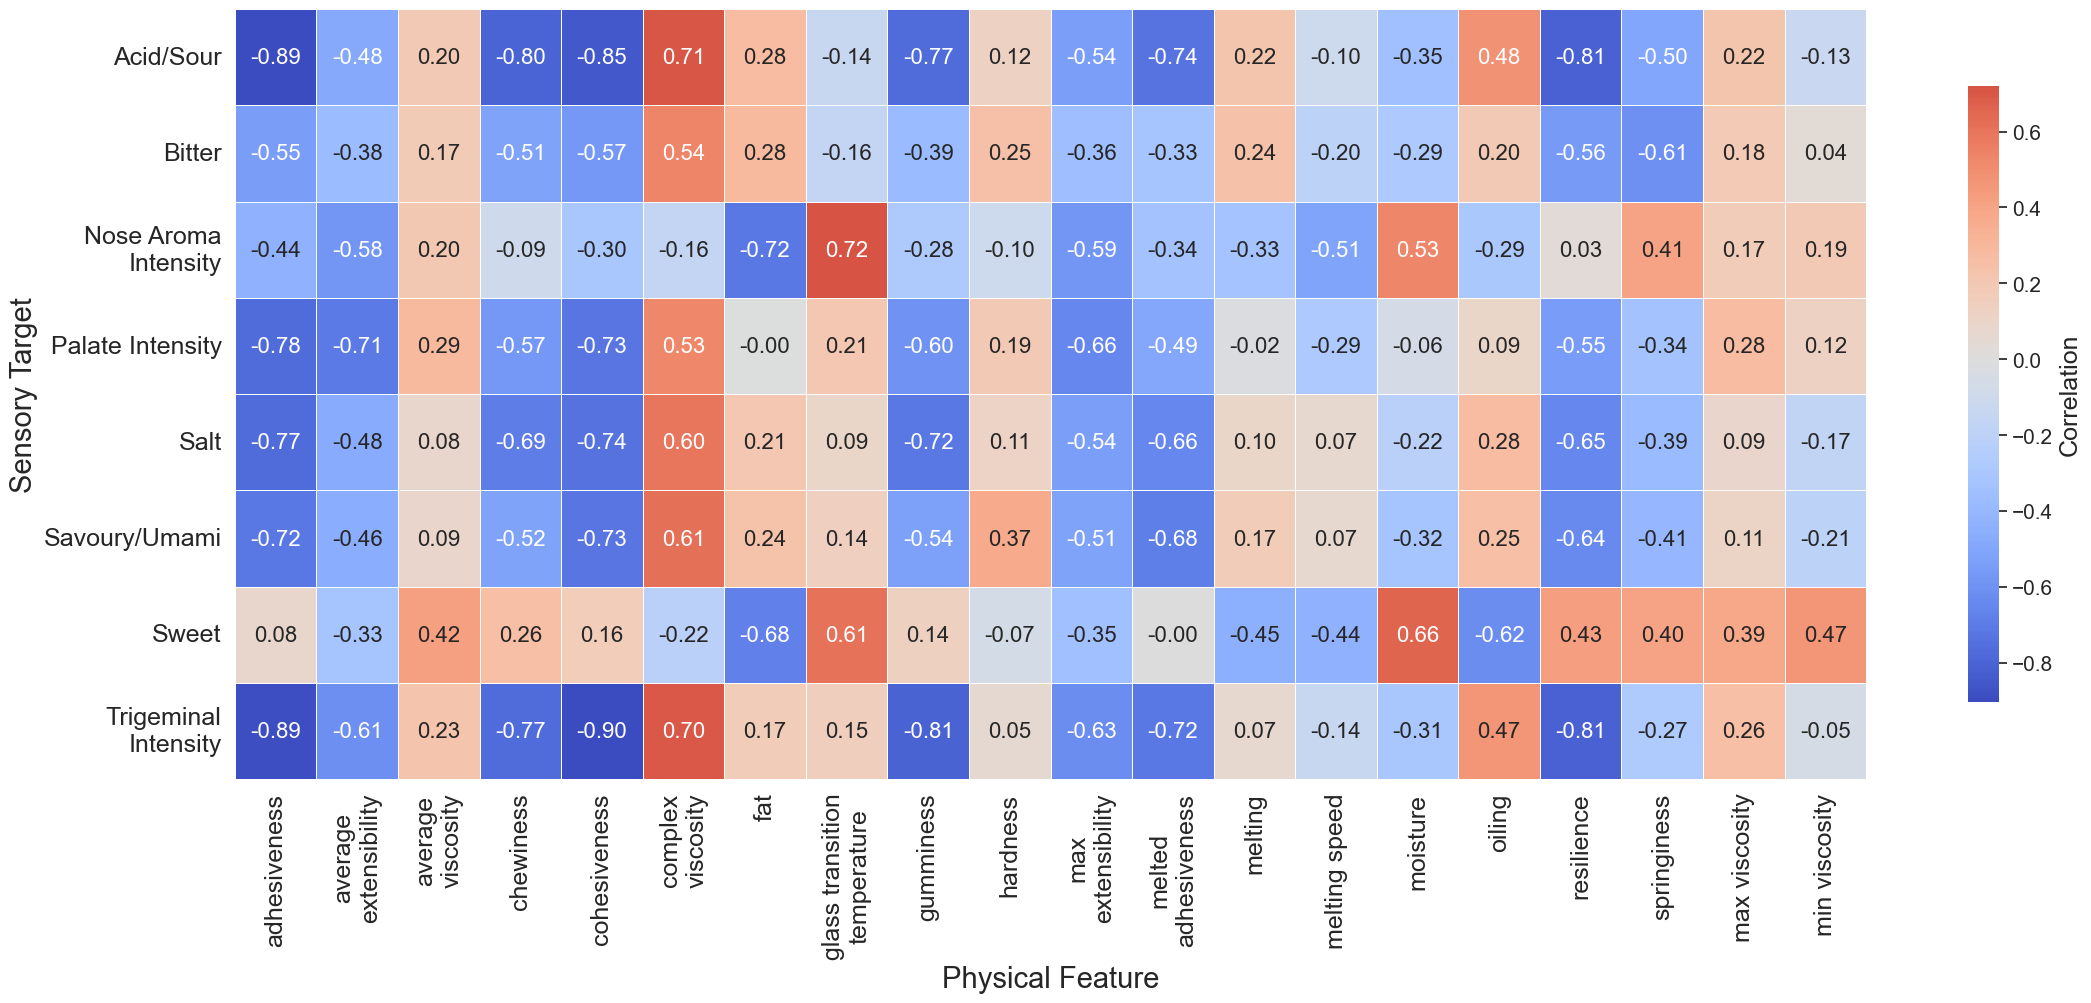

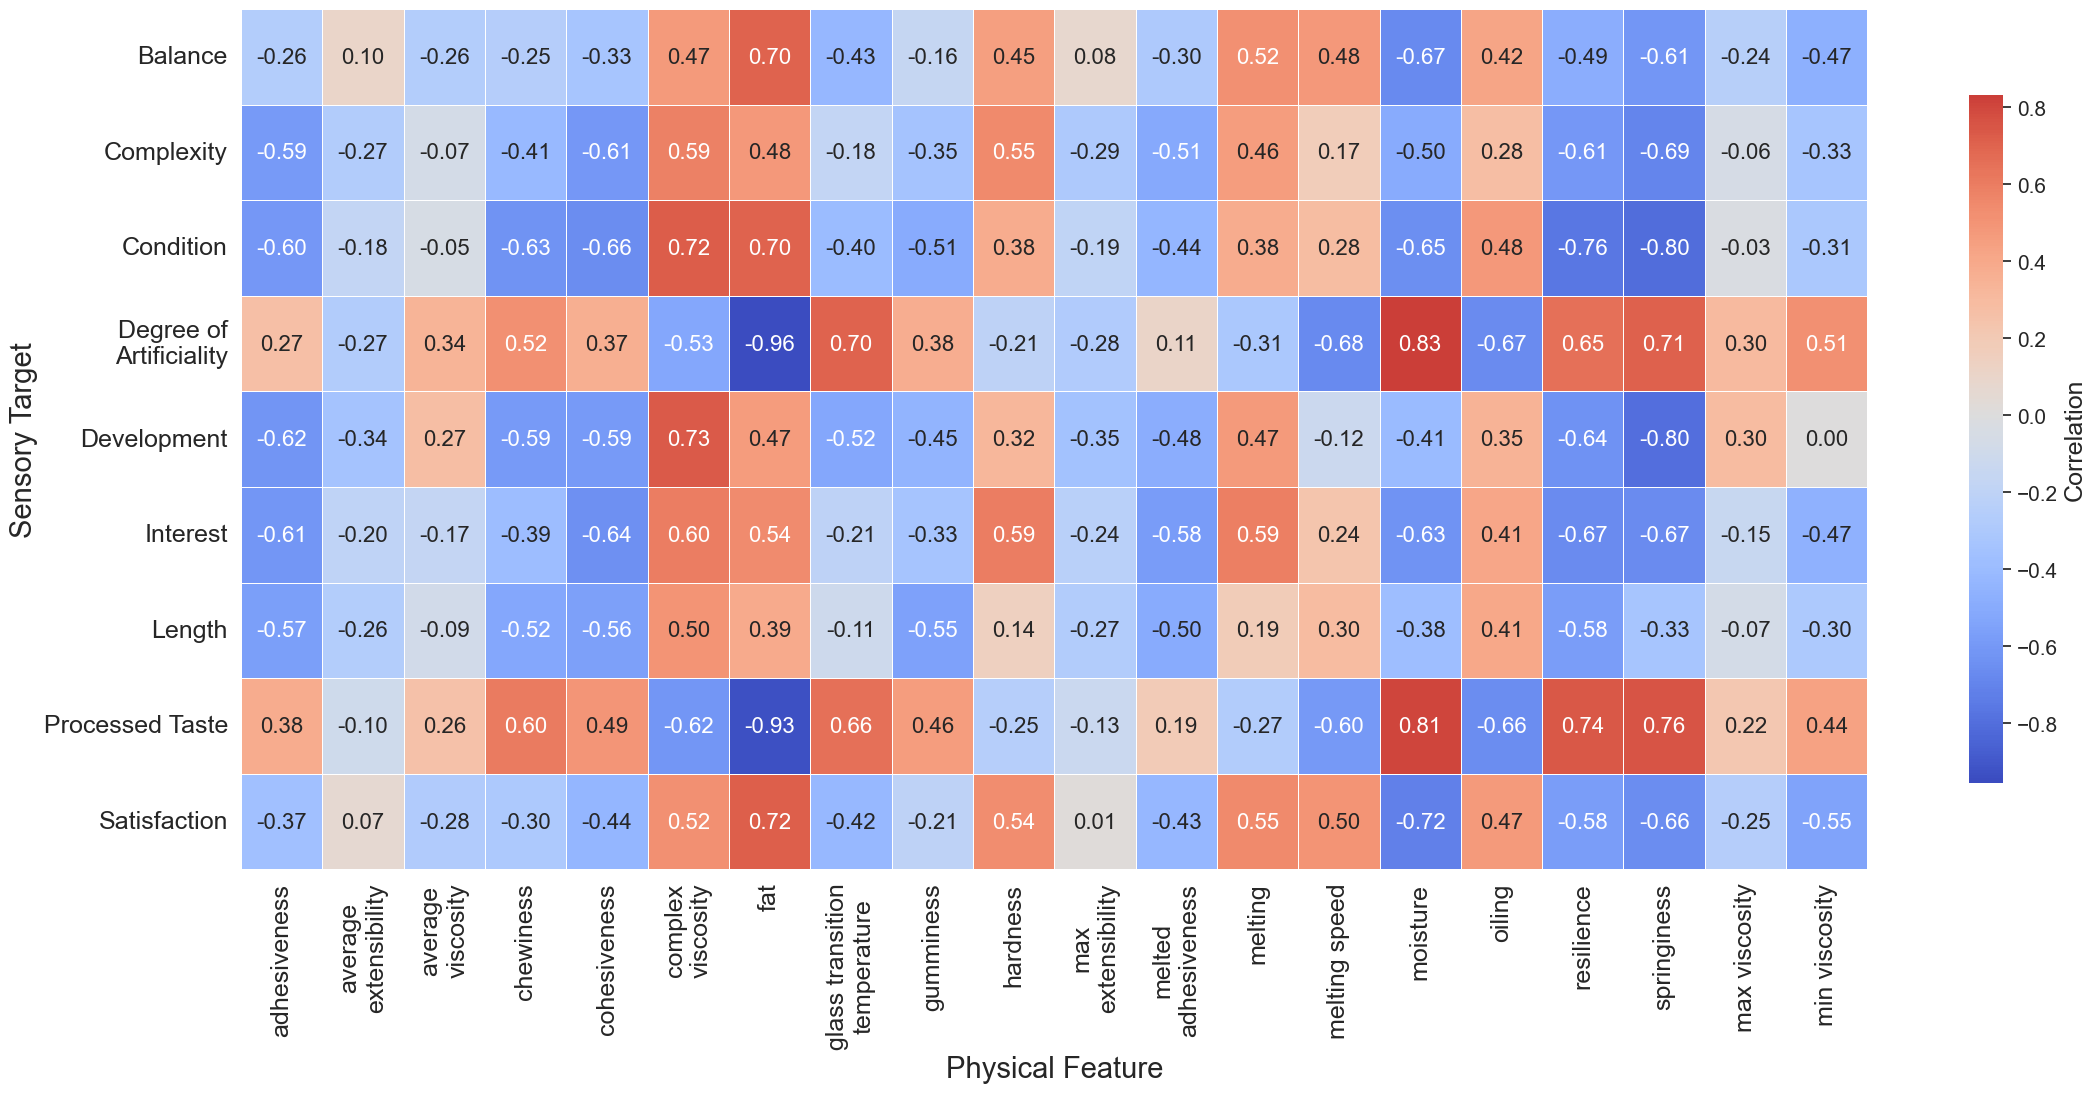

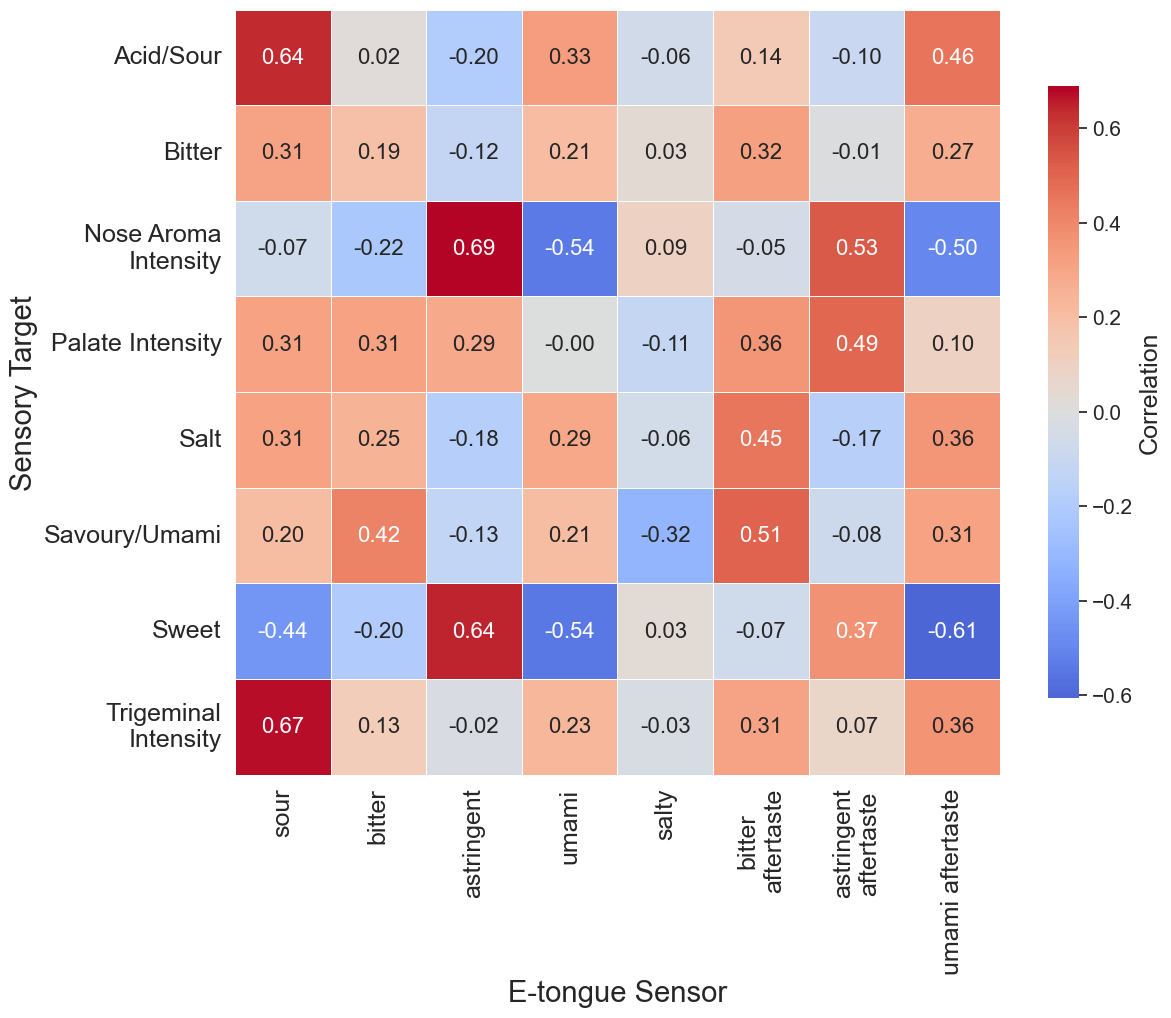

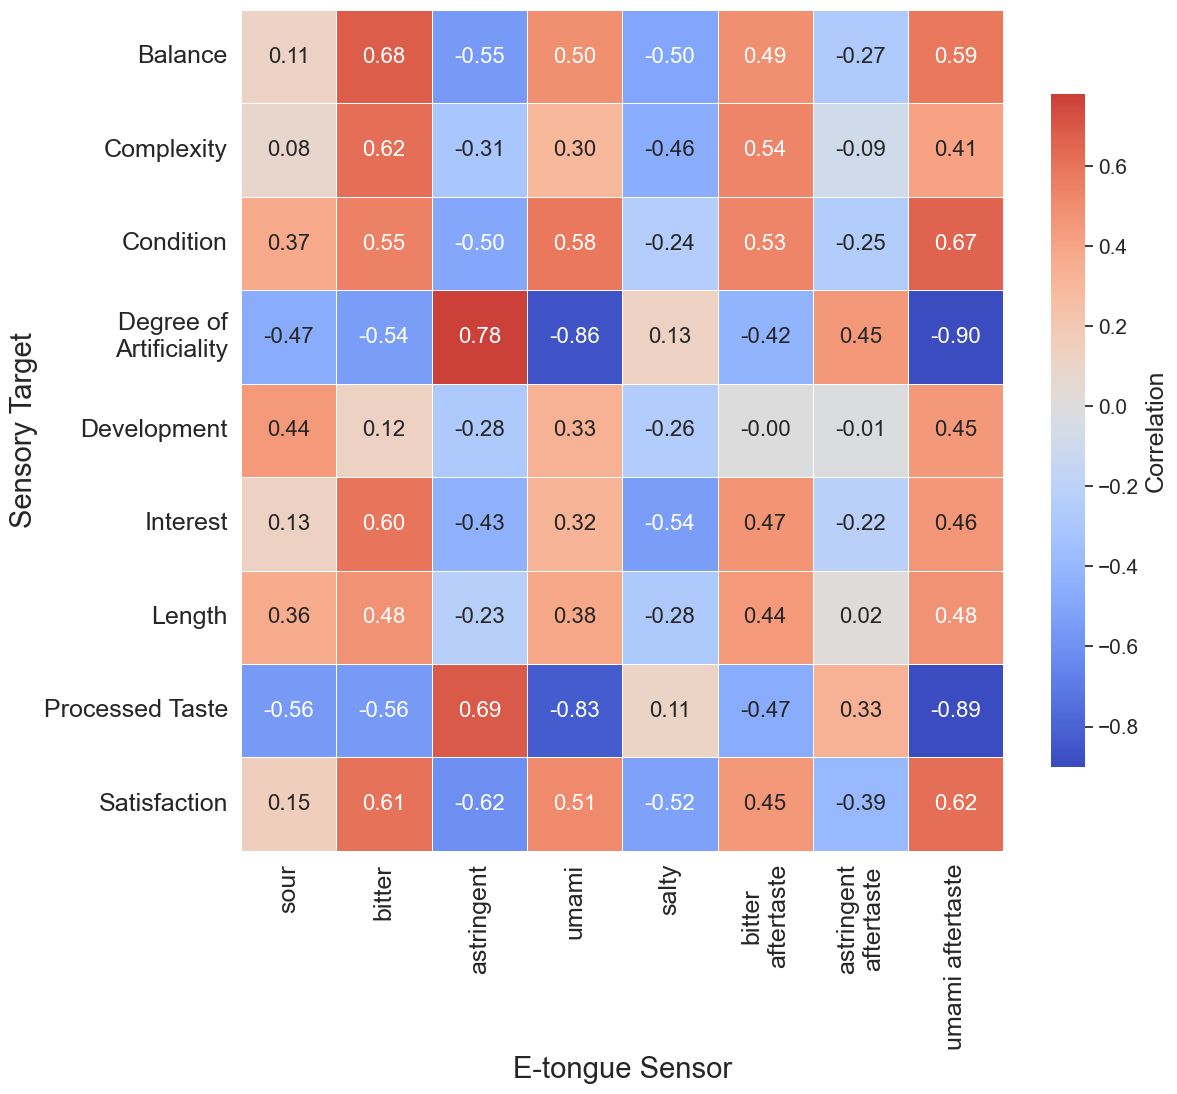

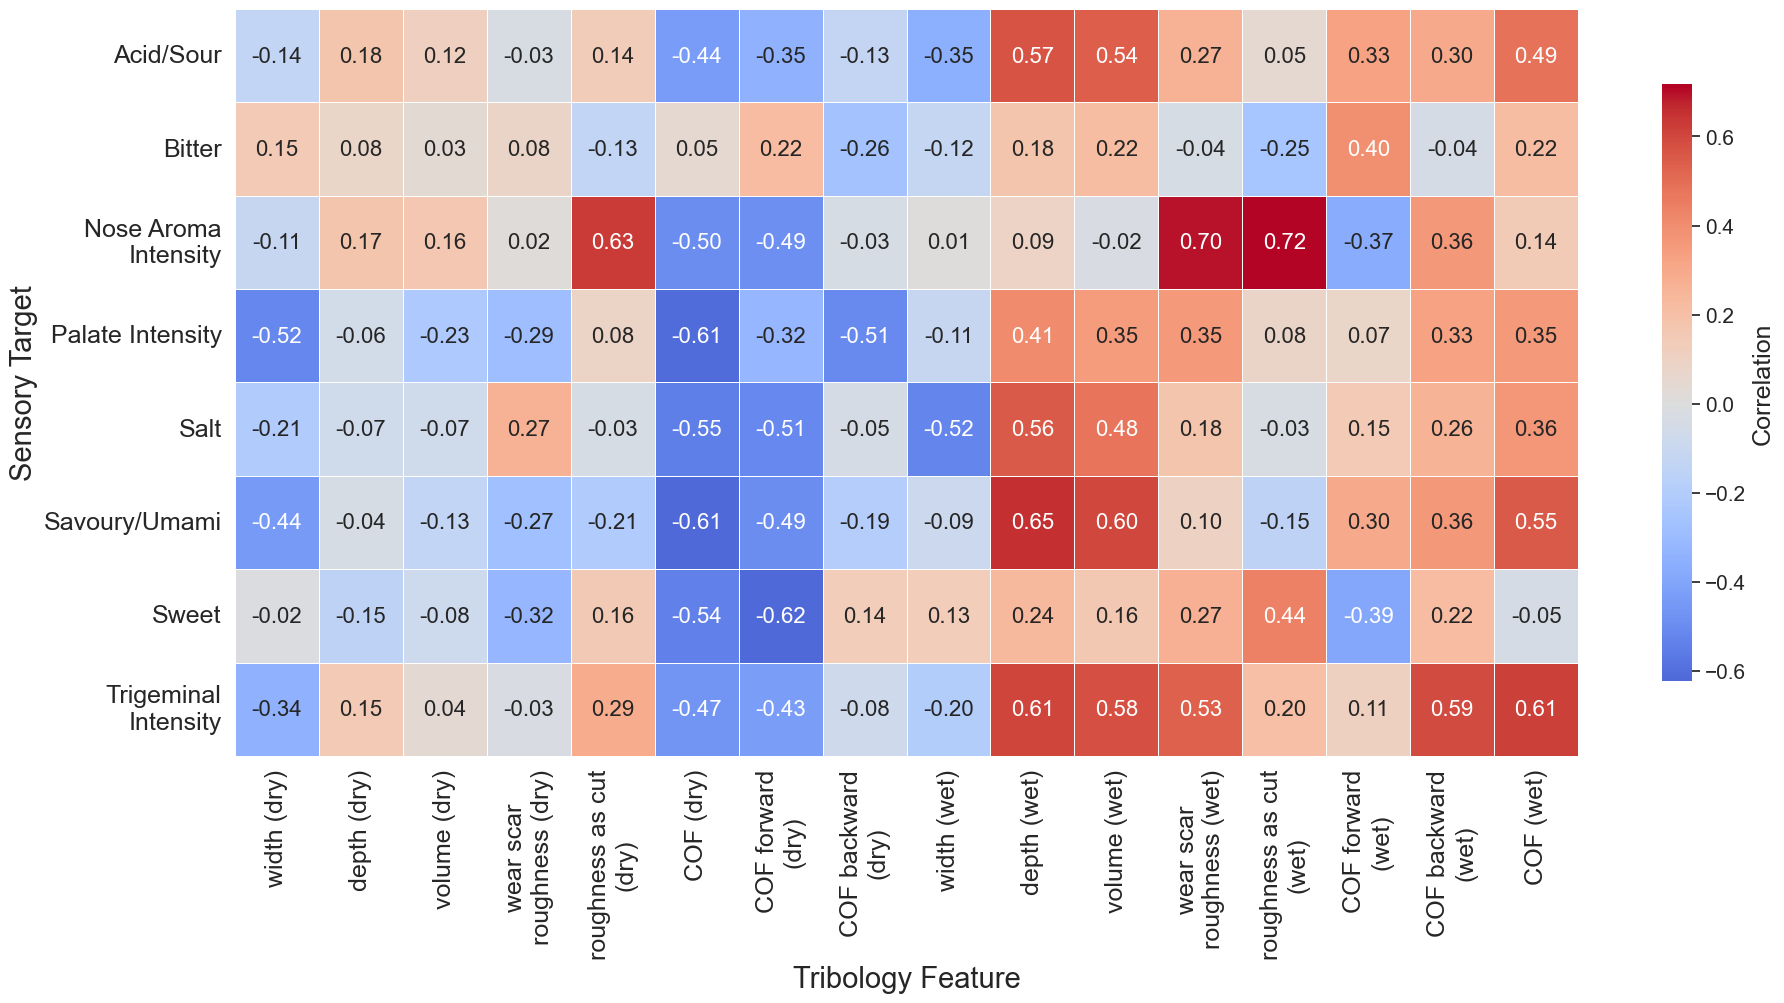

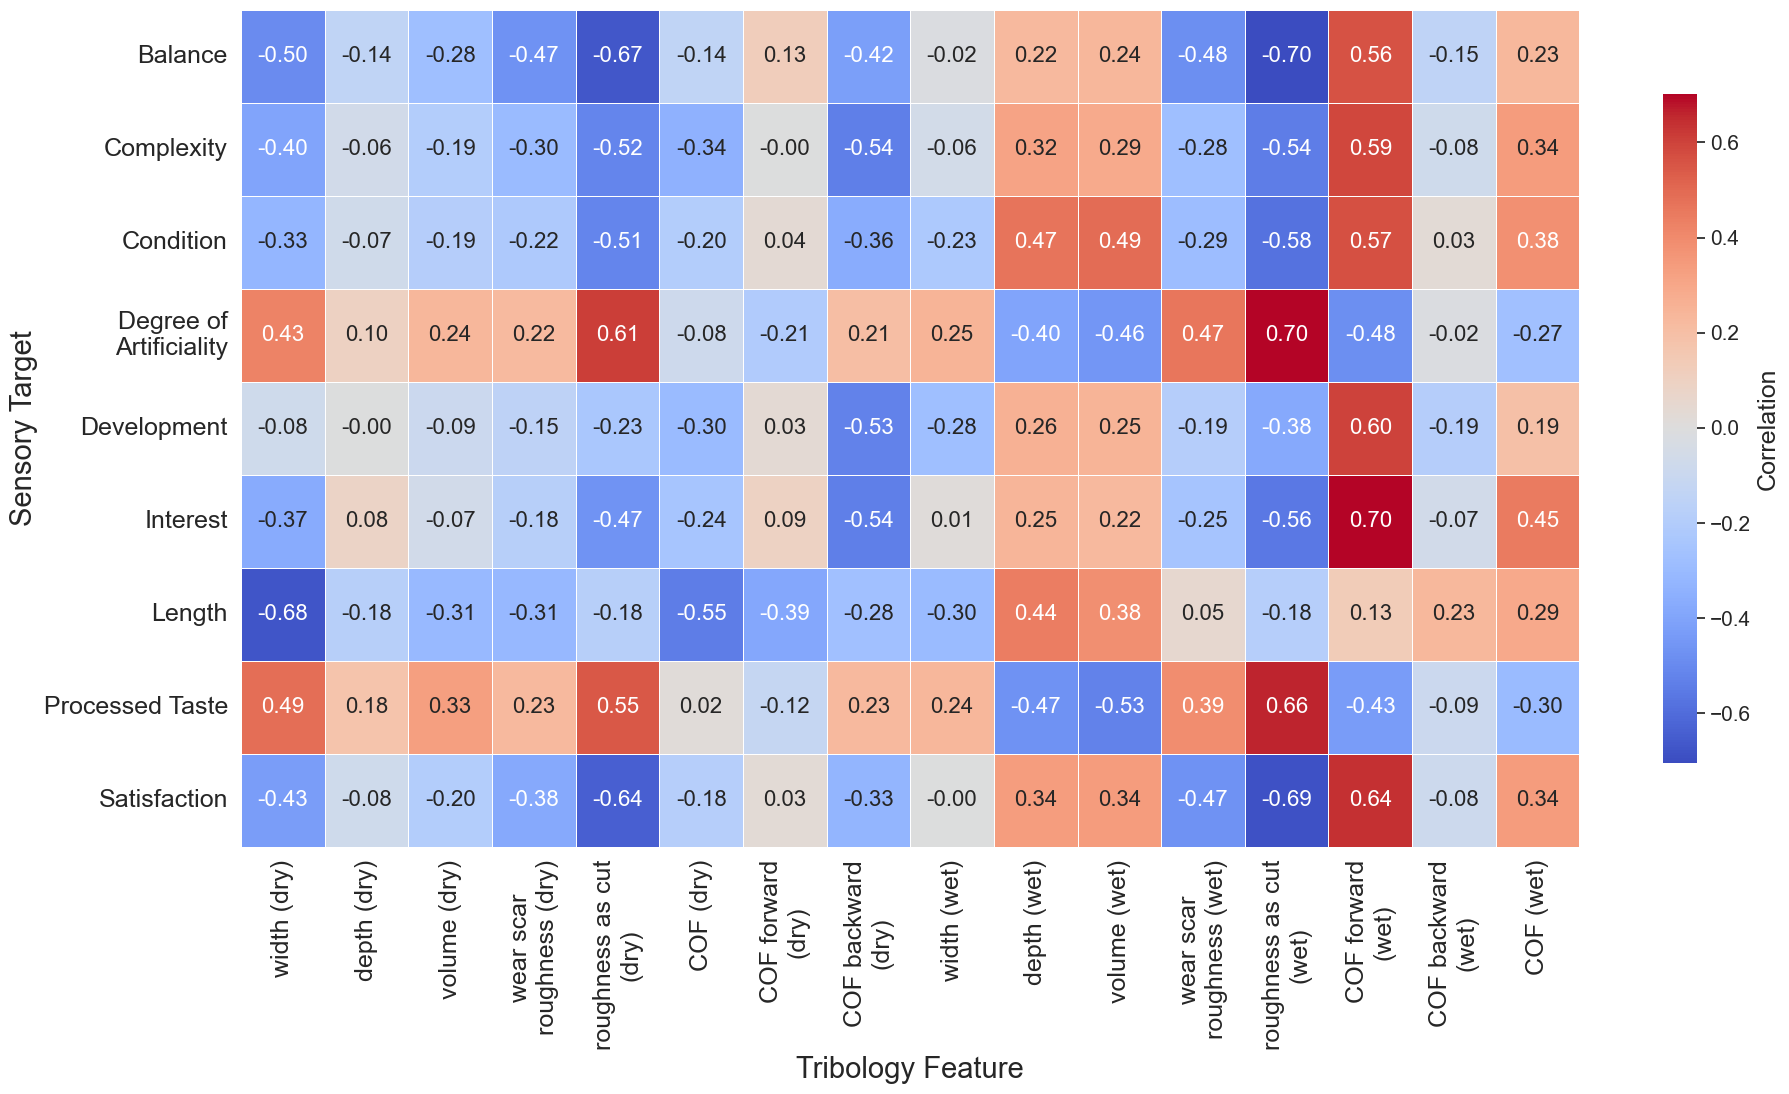

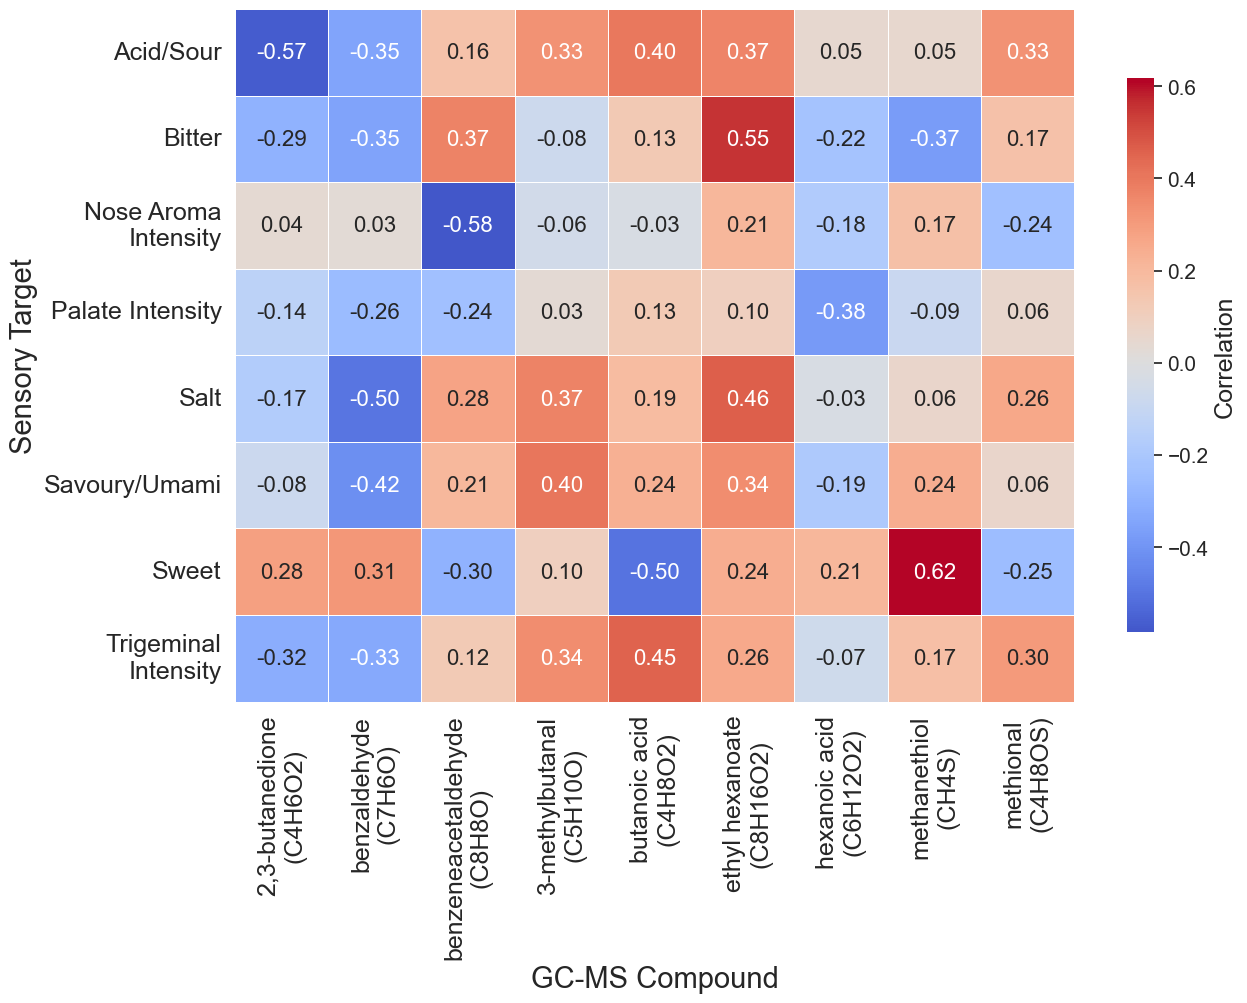

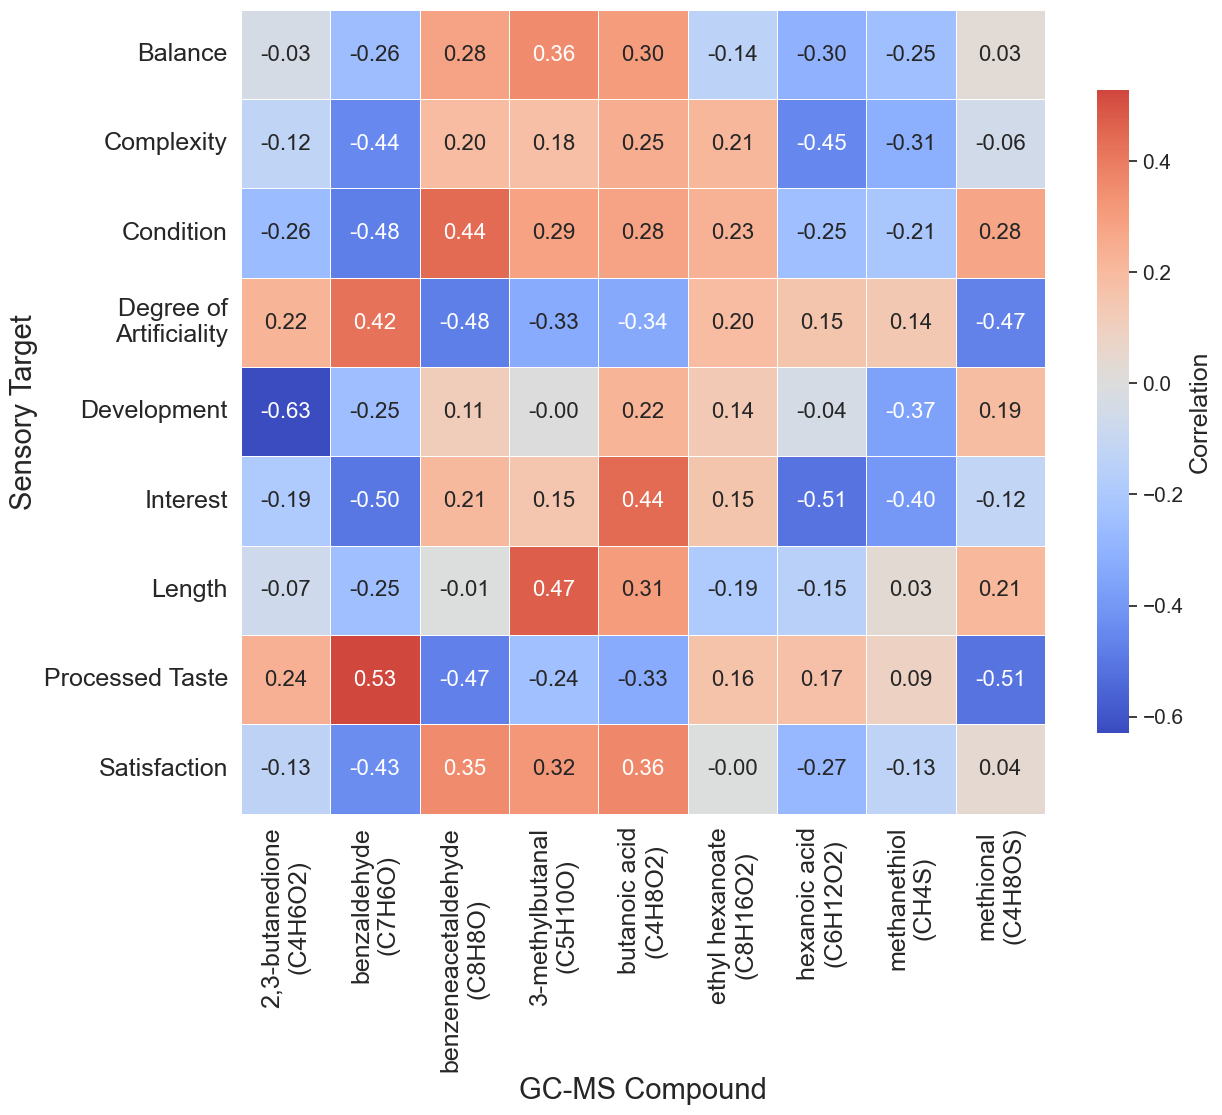

In [23]:
MODALITIES = {
    "Physical Feature": physical,
    "E-tongue Sensor": etongue,
    "Tribology Feature": tribology,
    "GC-MS Compound": compounds,
}
for xlabel, features in MODALITIES.items():
    for Y in (Y_taste, Y_quality):
        correlations = pd.DataFrame({target: features.corrwith(Y[target]) for target in Y.columns}).T
        correlation_heatmap(correlations, figsize=(0.9 * features.shape[1] + 5, 0.9 * Y.shape[1] + 3),
                            fontsize=18, xlabel=xlabel, ylabel="Sensory Target")

## 8 Modelling setup

### 8.1 Feature matrices

The four modalities are merged into one feature matrix per GC-MS representation.
Trials without a GC-MS value for a feature get the value 0.

In [24]:
def feature_matrix(gcms_features):
    X = (physical.join(etongue, how="inner").join(tribology, how="inner")
         .join(gcms_features, how="left").fillna(0))
    return X[X.index.isin(TRIALS)]


X_compound = feature_matrix(compounds)    # GC-MS as compounds
X_flavour = feature_matrix(odour_groups)  # GC-MS as odour groups
Y_taste = Y_taste.loc[X_compound.index]
Y_quality = Y_quality.loc[X_compound.index]

print(f"X (compounds):    {X_compound.shape}")
print(f"X (odour groups): {X_flavour.shape}")
print(f"Y taste: {Y_taste.shape} | Y quality: {Y_quality.shape}")

X (compounds):    (12, 53)
X (odour groups): (12, 53)
Y taste: (12, 8) | Y quality: (12, 9)


### 8.2 Model functions

Steps inside every leave-one-out fold, using the eleven training trials only:

1. Remove features that are constant in the training fold.
2. Rank the features by their absolute Pearson correlation with the targets, aggregated
   over the targets by the mean or the maximum, and keep the top K (if K is given).
3. Standardise the features and fit the model. Regularisation parameters and the number
   of PLS components are chosen by an inner three-fold cross-validation.

In [25]:
def corr_rank_features(X_train, Y_train, agg="mean"):
    """Rank features by their mean or max absolute correlation with the targets."""
    scores = {}
    for feature in X_train.columns:
        correlations = [abs(X_train[feature].corr(Y_train[target])) for target in Y_train.columns]
        correlations = [c for c in correlations if np.isfinite(c)]
        if not correlations:
            scores[feature] = 0.0
        else:
            scores[feature] = max(correlations) if agg == "max" else np.mean(correlations)
    return pd.Series(scores).sort_values(ascending=False)


def scaled(estimator):
    """Pipeline that standardises the features before the estimator is fitted."""
    return make_pipeline(StandardScaler(), estimator)


def pls_setup(X, n_components, rank_safe):
    """Columns and number of components that PLSR can use on the block X.

    With rank_safe=True, columns that are constant in X are dropped and the number of
    components is limited to the rank of X.
    """
    if not rank_safe:
        return list(X.columns), min(n_components, len(X) - 1, X.shape[1])
    columns = X.columns[X.std(ddof=0) > 1e-12].tolist()
    if not columns:
        return [], 0
    rank = int(np.linalg.matrix_rank(StandardScaler().fit_transform(X[columns])))
    return columns, int(max(0, min(n_components, len(X) - 1, len(columns), rank)))


def fit_predict_pls(X_train, Y_train, X_test, rank_safe):
    """PLSR with the number of components chosen by the inner cross-validation."""
    best_n, best_r2 = 1, -np.inf
    for n_components in range(1, MAX_PLS_COMPONENTS + 1):
        r2_inner = []
        for fit_rows, val_rows in INNER_CV.split(X_train):
            columns, n = pls_setup(X_train.iloc[fit_rows], n_components, rank_safe)
            if n < 1:
                continue
            pls = scaled(PLSRegression(n_components=n))
            pls.fit(X_train.iloc[fit_rows][columns], Y_train.iloc[fit_rows])
            Y_hat = pls.predict(X_train.iloc[val_rows][columns])
            r2_inner.append(np.mean([r2_score(Y_train.iloc[val_rows, j], Y_hat[:, j])
                                     for j in range(Y_train.shape[1])]))
        if r2_inner and np.mean(r2_inner) > best_r2:
            best_n, best_r2 = n_components, np.mean(r2_inner)

    columns, n = pls_setup(X_train, best_n, rank_safe)
    pls = scaled(PLSRegression(n_components=max(1, n))).fit(X_train[columns], Y_train)
    return pls.predict(X_test[columns])[0], best_n


def fit_predict(model, X_train, Y_train, X_test, rank_safe=False):
    """Fit one model on a training fold and predict the left-out trial.

    Returns the prediction and, for PLSR, the selected number of components.
    """
    if model == "pls":
        return fit_predict_pls(X_train, Y_train, X_test, rank_safe)
    if model == "rf":  # single-task: one forest per target
        forests = [RandomForestRegressor(**RF_PARAMS).fit(X_train, Y_train[target])
                   for target in Y_train.columns]
        return np.array([forest.predict(X_test)[0] for forest in forests]), None
    if model == "ridge":
        estimator, y_train = RidgeCV(alphas=RIDGE_ALPHAS), Y_train
    elif model == "enet":
        estimator, y_train = MultiTaskElasticNetCV(**ENET_PARAMS), Y_train
    elif model == "enet_single":  # one target only
        estimator, y_train = ElasticNetCV(**ENET_PARAMS), Y_train.iloc[:, 0]
    return np.ravel(scaled(estimator).fit(X_train, y_train).predict(X_test)), None


def loo_predict(X, Y, model, k=None, agg="mean", rank_safe=False):
    """Leave-one-out predictions with all preprocessing done inside each fold.

    Returns the predictions, the features used per fold and the PLS components per fold.
    """
    pred = pd.DataFrame(index=Y.index, columns=Y.columns, dtype=float)
    features, n_components = [], []
    for train, test in LeaveOneOut().split(X):
        X_train, X_test, Y_train = X.iloc[train], X.iloc[test], Y.iloc[train]
        varying = VarianceThreshold(0.0).fit(X_train).get_support()
        X_train, X_test = X_train.loc[:, varying], X_test.loc[:, varying]
        if k is not None:
            selected = corr_rank_features(X_train, Y_train, agg).head(k).index.tolist()
            X_train, X_test = X_train[selected], X_test[selected]
        pred.iloc[test[0]], n = fit_predict(model, X_train, Y_train, X_test, rank_safe)
        features.append(list(X_train.columns))
        n_components.append(n)
    return pred, features, n_components


def score_table(Y, pred):
    """R2, MAE and RMSE per target, sorted by R2."""
    rows = [{"Target": target,
             "R2": round(r2_score(Y[target], pred[target]), 3),
             "MAE": round(mean_absolute_error(Y[target], pred[target]), 3),
             "RMSE": round(np.sqrt(mean_squared_error(Y[target], pred[target])), 3)}
            for target in Y.columns]
    return pd.DataFrame(rows).set_index("Target").sort_values("R2", ascending=False)


def fit_model(X, Y, model, k_values=None, agg="mean", rank_safe=False):
    """Evaluate a model with leave-one-out cross-validation.

    With k_values, the model is run for every K and the K with the highest mean R2 is kept.
    """
    if k_values is None:
        runs, sweep, best_k = {None: loo_predict(X, Y, model, rank_safe=rank_safe)}, None, None
    else:
        runs = {k: loo_predict(X, Y, model, k, agg, rank_safe) for k in k_values if k <= X.shape[1]}
        sweep = pd.Series({k: round(np.mean([r2_score(Y[target], pred[target]) for target in Y.columns]), 3)
                           for k, (pred, _, _) in runs.items()}, name="Mean R2").rename_axis("K")
        best_k = int(sweep.idxmax())
    pred, features, n_components = runs[best_k]
    return dict(model=model, Y=Y, pred=pred, scores=score_table(Y, pred), k=best_k, sweep=sweep,
                features=features, n_components=n_components)


def selection_frequency(result):
    """Number of folds in which each feature was selected."""
    return pd.Series(Counter(feature for fold in result["features"] for feature in fold),
                     name="Folds selected")


def stable_features(result):
    """Features selected in at least STABLE_MIN_FOLDS folds."""
    frequency = selection_frequency(result)
    return frequency[frequency >= STABLE_MIN_FOLDS].index.tolist()


def most_frequent(values):
    """Most frequent value of a list (the smallest one in case of a tie)."""
    return max(set(values), key=values.count)


MODELS = {}  # model name -> result, used for the summary tables at the end


def mean_scores(result):
    """One-line summary: number of selected features, mean R2 and mean MAE over the targets."""
    scores = result["scores"]
    k = "all features" if result["k"] is None else f"K = {result['k']}"
    return f"{k} | Mean R2 = {scores['R2'].mean():.3f} | Mean MAE = {scores['MAE'].mean():.3f}"


def report(name, description, result):
    """Print and store the results of one model."""
    MODELS[name] = {**result, "description": description}
    print(f"{name}: {description}")
    print(mean_scores(result))
    display(result["scores"])
    for group, part in result.get("parts", {"": result}).items():
        if group:
            print(f"Sub-group {group}: {mean_scores(part)}")
        if part.get("sweep") is not None:
            print("Mean R2 per K:")
            display(part["sweep"].to_frame().T)
        if part["model"] == "pls":
            n = part["n_components"]
            print(f"Most frequent number of PLS components: {most_frequent(n)} "
                  f"({n.count(most_frequent(n))}/{len(n)} folds)")
        if part.get("sweep") is not None:
            print("Feature selection frequency:")
            display(selection_frequency(part).sort_values(ascending=False).to_frame())
    return result


def run(name, description, X, Y, model, k_values=None, agg="mean", rank_safe=False):
    """Fit and report one model."""
    return report(name, description, fit_model(X, Y, model, k_values, agg, rank_safe))


def run_subgroups(name, description, X, Y, rank_safe=False):
    """PLSR with a K sweep, fitted separately for the off-flavour and the holistic targets.

    The joint R2 and MAE are the means over all nine quality targets.
    """
    parts = {group: fit_model(X, Y[targets], "pls", K_VALUES, "max", rank_safe)
             for group, targets in SUBGROUPS.items()}
    pred = pd.concat([part["pred"] for part in parts.values()], axis=1)[Y.columns]
    joint = dict(model="pls", Y=Y, pred=pred, parts=parts,
                 scores=pd.concat([part["scores"] for part in parts.values()])
                 .sort_values("R2", ascending=False),
                 k="; ".join(str(part["k"]) for part in parts.values()))
    return report(name, description, joint)

### 8.3 Figures for the model results

In [26]:
ALGORITHM_STYLE = {  # colour, line style, marker, marker size
    "pls": ("#0072B2", "-", "o", 6.2),
    "enet": ("#D55E00", "--", "s", 5.5),
    "rf": ("#009E73", "-.", "^", 8.0),
}


def plot_k_sweeps(curves):
    """Mean R2 against the number of selected features; the best K of each model is circled."""
    sizes = {"axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10}
    with plt.rc_context({**THESIS_STYLE, **sizes}):
        fig, ax = plt.subplots(figsize=(6.8, 4.0))
        ax.axhline(0, color="0.55", linewidth=0.9, zorder=1)
        for label, result in curves.items():
            colour, style, marker, size = ALGORITHM_STYLE[result["model"]]
            sweep = result["sweep"]
            ax.plot(sweep.index, sweep.values, linestyle=style, marker=marker, color=colour,
                    linewidth=1.8, markersize=size, markeredgecolor="white", markeredgewidth=0.8,
                    label=label, zorder=3)
            ax.plot(sweep.idxmax(), sweep.max(), marker="o", markersize=size + 7.5, linestyle="none",
                    markerfacecolor="none", markeredgecolor=colour, markeredgewidth=1.6, zorder=4)
        ax.set_xlabel("Number of selected features $K$")
        ax.set_ylabel("Mean $R^2$")
        ax.set_xticks(list(K_VALUES))
        ax.set_xlim(1.6, 12.4)
        ax.margins(y=0.12)
        ax.xaxis.grid(False)
        sns.despine(ax=ax)
        ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.17))
        plt.show()


def plot_predicted_vs_observed(result, targets, ncols):
    """Predicted against observed panel scores for the given targets."""
    Y, pred, scores = result["Y"], result["pred"], result["scores"]
    nrows = int(np.ceil(len(targets) / ncols))
    with plt.rc_context(THESIS_STYLE):
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.8 * nrows), squeeze=False)
        for ax, target in zip(axes.ravel(), targets):
            low = min(Y[target].min(), pred[target].min()) - 0.25
            high = max(Y[target].max(), pred[target].max()) + 0.25
            ax.plot([low, high], [low, high], color="0.6", linestyle="--", linewidth=1.2, zorder=1)
            ax.scatter(Y[target], pred[target], s=70, color="#0072B2", edgecolor="white", zorder=3)
            ax.set_xlim(low, high)
            ax.set_ylim(low, high)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"{target}\n$R^2$ = {scores.loc[target, 'R2']:.3f},  "
                         f"MAE = {scores.loc[target, 'MAE']:.3f}", fontsize=18, pad=10)
            ax.tick_params(labelsize=13)
        for ax in axes[-1]:
            ax.set_xlabel("Observed panel score", fontsize=18)
        for ax in axes[:, 0]:
            ax.set_ylabel("Predicted panel score", fontsize=18)
        sns.despine()
        plt.tight_layout()
        plt.show()


def plot_coefficients(coefs, fontsize):
    """Heatmap of model coefficients (features as rows, targets as columns)."""
    limit = np.abs(coefs.values).max()
    with plt.rc_context(THESIS_STYLE):
        fig, ax = plt.subplots(figsize=(1.35 * coefs.shape[1] + 3.4, 0.62 * coefs.shape[0] + 1.4))
        sns.heatmap(coefs, cmap="RdBu_r", center=0, vmin=-limit, vmax=limit, annot=True, fmt=".2f",
                    annot_kws={"fontsize": fontsize}, linewidths=0.6, linecolor="white",
                    cbar_kws={"label": "Coefficient"}, ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(labelsize=fontsize)
        plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
        plt.setp(ax.get_yticklabels(), rotation=0)
        colorbar = ax.collections[0].colorbar
        colorbar.ax.yaxis.label.set_size(fontsize)
        colorbar.ax.tick_params(labelsize=fontsize)
        plt.tight_layout()
        plt.show()

## 9 Taste and aroma models

### 9.1 Without feature selection (M1 to M3)

In [27]:
M1 = run("M1", "Ridge, no feature selection", X_compound, Y_taste, "ridge")
M2 = run("M2", "Multi-task Elastic Net, no feature selection", X_compound, Y_taste, "enet")
M3 = run("M3", "PLSR, no feature selection", X_compound, Y_taste, "pls")

M1: Ridge, no feature selection
all features | Mean R2 = 0.033 | Mean MAE = 0.382


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.350,0.292,0.366
Acid/Sour,0.194,0.463,0.536
Palate Intensity,0.143,0.441,0.516
Savoury/Umami,0.072,0.438,0.567
Sweet,-0.001,0.286,0.340
Salt,-0.013,0.327,0.398
Nose Aroma Intensity,-0.108,0.365,0.440
Bitter,-0.371,0.446,0.550


M2: Multi-task Elastic Net, no feature selection
all features | Mean R2 = 0.094 | Mean MAE = 0.365


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.564,0.244,0.300
Acid/Sour,0.416,0.390,0.457
Palate Intensity,0.259,0.382,0.480
Salt,0.097,0.310,0.376
Bitter,-0.038,0.348,0.479
Savoury/Umami,-0.056,0.504,0.605
Nose Aroma Intensity,-0.153,0.397,0.449
Sweet,-0.338,0.342,0.393


M3: PLSR, no feature selection
all features | Mean R2 = 0.034 | Mean MAE = 0.372


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.375,0.278,0.359
Acid/Sour,0.349,0.416,0.482
Savoury/Umami,0.333,0.379,0.481
Salt,0.242,0.305,0.344
Bitter,0.036,0.310,0.461
Palate Intensity,-0.035,0.484,0.567
Sweet,-0.340,0.328,0.394
Nose Aroma Intensity,-0.687,0.480,0.543


Most frequent number of PLS components: 1 (8/12 folds)


### 9.2 With feature selection (M4 to M6)

The features are ranked by their mean absolute correlation with the eight targets.

In [28]:
M4 = run("M4", "Multi-task Elastic Net, K sweep", X_compound, Y_taste, "enet", K_VALUES)

M4: Multi-task Elastic Net, K sweep
K = 3 | Mean R2 = 0.269 | Mean MAE = 0.334


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.711,0.208,0.244
Acid/Sour,0.700,0.282,0.328
Nose Aroma Intensity,0.346,0.268,0.338
Palate Intensity,0.331,0.416,0.456
Salt,0.233,0.300,0.346
Savoury/Umami,0.217,0.458,0.521
Bitter,-0.064,0.383,0.485
Sweet,-0.319,0.355,0.391


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.22,0.269,0.192,0.206,0.172,0.218,0.214,0.258,0.209,0.173,0.191


Feature selection frequency:


,Folds selected
adhesiveness,12
cohesiveness,12
resilience,10
complex viscosity,1
chewiness,1


In [ ]:
M5 = run("M5", "PLSR, K sweep", X_compound, Y_taste, "pls", K_VALUES)

In [ ]:
M6 = run("M6", "Random Forest, K sweep", X_compound, Y_taste, "rf", K_VALUES)

In [ ]:
plot_k_sweeps({"M4: Elastic Net": M4, "M5: PLSR": M5, "M6: Random Forest": M6})
plot_predicted_vs_observed(M4, ["Trigeminal Intensity", "Palate Intensity", "Sweet"], ncols=3)

**Coefficients of M4.** The model is refitted on all twelve trials with the stable
features only. This fit is not cross-validated and only shows the direction and size
of the coefficients.

In [ ]:
features = sorted(stable_features(M4))
enet = scaled(MultiTaskElasticNetCV(**ENET_PARAMS)).fit(X_compound[features], Y_taste)
coefs = pd.DataFrame(enet[-1].coef_, index=Y_taste.columns, columns=features)
plot_coefficients(coefs.loc[M4["scores"].index].T, fontsize=15)

### 9.3 GC-MS as odour groups (M7)

In [ ]:
M7 = run("M7", "Multi-task Elastic Net, K sweep, odour groups", X_flavour, Y_taste, "enet", K_VALUES)

### 9.4 One model per target (M8)

A single-task Elastic Net is fitted for every target, and K is chosen per target.
Because K is chosen on the outer cross-validation result of each target separately,
these values are optimistically biased and serve as an upper bound only.

In [ ]:
rows, preds = [], []
for target in Y_taste.columns:
    fits = {k: loo_predict(X_flavour, Y_taste[[target]], "enet_single", k) for k in range(2, 11)}
    r2 = {k: r2_score(Y_taste[target], pred[target]) for k, (pred, _, _) in fits.items()}
    best_k = max(r2, key=r2.get)  # first K with the highest R2
    pred, features, _ = fits[best_k]
    top = Counter(feature for fold in features for feature in fold).most_common(3)
    rows.append({"Target": target,
                 "R2": round(r2[best_k], 3),
                 "MAE": round(mean_absolute_error(Y_taste[target], pred[target]), 3),
                 "Best K": best_k,
                 "Top features": ", ".join(f"{feature} ({n})" for feature, n in top)})
    preds.append(pred)

M8 = dict(model="enet_single", Y=Y_taste, pred=pd.concat(preds, axis=1), k="per target",
          scores=pd.DataFrame(rows).set_index("Target").sort_values("R2", ascending=False))
MODELS["M8"] = {**M8, "description": "Single-task Elastic Net, K per target, odour groups"}
print(f"M8: Mean R2 = {M8['scores']['R2'].mean():.3f} | Mean MAE = {M8['scores']['MAE'].mean():.3f}")
display(M8["scores"])

### 9.5 Contribution of the physical features (M9 to M12)

M4 (Elastic Net) and M5 (PLSR) are repeated without the physical features and with
the physical features only.

In [35]:
M9 = run("M9", "Multi-task Elastic Net, K sweep, without physical",
         X_compound.drop(columns=physical.columns), Y_taste, "enet", K_VALUES)

M9: Multi-task Elastic Net, K sweep, without physical
K = 3 | Mean R2 = -0.493 | Mean MAE = 0.487


,R2,MAE,RMSE
Target,,,
Sweet,-0.128,0.325,0.361
Nose Aroma Intensity,-0.266,0.377,0.470
Palate Intensity,-0.500,0.552,0.683
Acid/Sour,-0.527,0.636,0.738
Savoury/Umami,-0.573,0.598,0.738
Trigeminal Intensity,-0.593,0.503,0.573
Salt,-0.645,0.431,0.507
Bitter,-0.714,0.475,0.615


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.602,-0.493,-0.528,-0.87,-0.819,-0.746,-0.72,-0.706,-0.846,-0.713,-0.953


Feature selection frequency:


,Folds selected
COF (dry),12
COF forward (dry),9
depth (wet),7
sour,2
umami aftertaste,2
benzaldehyde (C7H6O),1
COF (wet),1
COF backward (wet),1
"2,3-butanedione (C4H6O2)",1


In [ ]:
M10 = run("M10", "Multi-task Elastic Net, K sweep, physical only",
          X_compound[physical.columns], Y_taste, "enet", K_VALUES)

In [37]:
M11 = run("M11", "PLSR, K sweep, without physical",
          X_compound.drop(columns=physical.columns), Y_taste, "pls", K_VALUES)

M11: PLSR, K sweep, without physical
K = 10 | Mean R2 = -0.260 | Mean MAE = 0.422


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.140,0.351,0.421
Acid/Sour,0.046,0.405,0.584
Savoury/Umami,-0.176,0.544,0.638
Bitter,-0.214,0.348,0.518
Salt,-0.296,0.386,0.450
Palate Intensity,-0.351,0.511,0.648
Nose Aroma Intensity,-0.611,0.473,0.531
Sweet,-0.615,0.362,0.432


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.677,-0.598,-0.375,-0.525,-0.432,-0.328,-0.344,-0.287,-0.259,-0.274,-0.275


Most frequent number of PLS components: 1 (12/12 folds)
Feature selection frequency:


,Folds selected
depth (wet),12
COF (dry),12
sour,12
volume (wet),12
COF forward (dry),11
umami aftertaste,9
COF (wet),9
ethyl hexanoate (C8H16O2),9
benzaldehyde (C7H6O),8
umami,5


In [38]:
M12 = run("M12", "PLSR, K sweep, physical only",
          X_compound[physical.columns], Y_taste, "pls", K_VALUES)

M12: PLSR, K sweep, physical only
K = 11 | Mean R2 = 0.240 | Mean MAE = 0.331


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.733,0.193,0.234
Acid/Sour,0.668,0.300,0.344
Salt,0.430,0.238,0.299
Palate Intensity,0.385,0.387,0.437
Savoury/Umami,0.359,0.407,0.471
Bitter,0.098,0.332,0.446
Nose Aroma Intensity,-0.315,0.435,0.479
Sweet,-0.435,0.360,0.408


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.167,0.151,0.013,0.071,0.141,0.188,0.167,0.226,0.213,0.24,0.21


Most frequent number of PLS components: 1 (9/12 folds)
Feature selection frequency:


,Folds selected
adhesiveness,12
cohesiveness,12
resilience,12
max extensibility,12
melted adhesiveness,12
chewiness,12
gumminess,12
complex viscosity,12
average extensibility,12
springiness,11


### 9.6 Additional analyses of M4

**Maximum instead of mean correlation.** Same model as M4, but the features are ranked
by their maximum absolute correlation with any of the targets.

In [39]:
M4_max = run("M4 (max)", "Multi-task Elastic Net, K sweep, max correlation",
             X_compound, Y_taste, "enet", K_VALUES, agg="max")

M4 (max): Multi-task Elastic Net, K sweep, max correlation
K = 4 | Mean R2 = 0.272 | Mean MAE = 0.328


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.691,0.198,0.252
Acid/Sour,0.680,0.293,0.338
Salt,0.378,0.254,0.312
Palate Intensity,0.296,0.410,0.468
Savoury/Umami,0.264,0.433,0.505
Bitter,0.081,0.325,0.450
Nose Aroma Intensity,0.004,0.370,0.417
Sweet,-0.222,0.339,0.376


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.243,0.247,0.271,0.268,0.215,0.168,-0.013,-0.085,0.05,0.107,0.127


Feature selection frequency:


,Folds selected
cohesiveness,12
adhesiveness,12
resilience,8
chewiness,6
gumminess,5
COF (wet),1
glass transition temperature,1
roughness as cut (wet),1
complex viscosity,1
melted adhesiveness,1


**Without cross-validation.** Feature selection and model fitting use all twelve trials,
and the model is evaluated on the same trials. This shows how strongly the performance
is overestimated when the selection is not part of the cross-validation.

In [40]:
k = M4["k"]
X_varying = X_compound.loc[:, VarianceThreshold(0.0).fit(X_compound).get_support()]
selected = corr_rank_features(X_varying, Y_taste, "mean").head(k).index.tolist()
enet = scaled(MultiTaskElasticNetCV(**ENET_PARAMS)).fit(X_varying[selected], Y_taste)
pred = pd.DataFrame(enet.predict(X_varying[selected]), index=Y_taste.index, columns=Y_taste.columns)

M4_no_cv = report("M4 (no CV)", "Multi-task Elastic Net, selection and fit on all trials",
                  dict(model="enet", Y=Y_taste, pred=pred, scores=score_table(Y_taste, pred), k=k))
print(f"Mean R2 with cross-validation: {M4['scores']['R2'].mean():.3f} | "
      f"without: {M4_no_cv['scores']['R2'].mean():.3f}")

M4 (no CV): Multi-task Elastic Net, selection and fit on all trials
K = 3 | Mean R2 = 0.605 | Mean MAE = 0.236


,R2,MAE,RMSE
Target,,,
Trigeminal Intensity,0.811,0.163,0.197
Acid/Sour,0.809,0.223,0.261
Nose Aroma Intensity,0.704,0.179,0.227
Palate Intensity,0.632,0.273,0.338
Salt,0.592,0.206,0.253
Savoury/Umami,0.525,0.340,0.406
Sweet,0.429,0.235,0.257
Bitter,0.334,0.267,0.383


Mean R2 with cross-validation: 0.269 | without: 0.605


## 10 Quality models

In all quality models the features are ranked by their maximum absolute correlation
with the targets.

### 10.1 Algorithms (N1 to N3)

In [41]:
N1 = run("N1", "PLSR, K sweep", X_compound, Y_quality, "pls", K_VALUES, agg="max")

N1: PLSR, K sweep
K = 5 | Mean R2 = 0.091 | Mean MAE = 0.665


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.483,0.879,1.117
Processed Taste,0.380,1.076,1.255
Satisfaction,0.144,0.637,0.741
Balance,0.075,0.520,0.638
Condition,0.075,0.486,0.535
Interest,-0.017,0.646,0.753
Development,-0.054,0.312,0.360
Length,-0.126,0.707,0.808
Complexity,-0.138,0.726,0.892


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.102,-0.092,0.068,0.091,-0.062,0.032,-0.001,0.032,0.019,0.001,0.004


Most frequent number of PLS components: 1 (10/12 folds)
Feature selection frequency:


,Folds selected
fat,12
umami aftertaste,12
umami,12
moisture,9
springiness,6
cohesiveness,1
astringent,1
melting speed,1
bitter,1
glass transition temperature,1


In [42]:
N2 = run("N2", "Multi-task Elastic Net, K sweep", X_compound, Y_quality, "enet", K_VALUES, agg="max")

N2: Multi-task Elastic Net, K sweep
K = 3 | Mean R2 = 0.039 | Mean MAE = 0.655


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.547,0.755,1.046
Processed Taste,0.260,1.045,1.372
Satisfaction,0.181,0.637,0.725
Balance,0.137,0.535,0.617
Interest,-0.008,0.577,0.749
Length,-0.105,0.710,0.801
Condition,-0.117,0.510,0.588
Development,-0.264,0.334,0.394
Complexity,-0.276,0.794,0.944


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.006,0.039,-0.491,-0.452,-0.52,-0.361,-0.205,-0.297,-0.236,-0.347,-0.264


Feature selection frequency:


,Folds selected
fat,12
umami aftertaste,12
umami,8
springiness,1
glass transition temperature,1
moisture,1
sour,1


In [43]:
N3 = run("N3", "Random Forest, K sweep", X_compound, Y_quality, "rf", K_VALUES, agg="max")

N3: Random Forest, K sweep
K = 3 | Mean R2 = 0.103 | Mean MAE = 0.632


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.555,0.766,1.036
Processed Taste,0.413,0.972,1.221
Satisfaction,0.299,0.564,0.671
Balance,0.131,0.512,0.619
Condition,0.077,0.469,0.535
Length,0.030,0.649,0.750
Interest,-0.016,0.666,0.752
Complexity,-0.070,0.728,0.865
Development,-0.491,0.366,0.428


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.084,0.103,-0.035,0.007,0.036,-0.007,-0.039,-0.131,-0.191,-0.223,-0.211


Feature selection frequency:


,Folds selected
fat,12
umami aftertaste,12
umami,8
springiness,1
glass transition temperature,1
moisture,1
sour,1


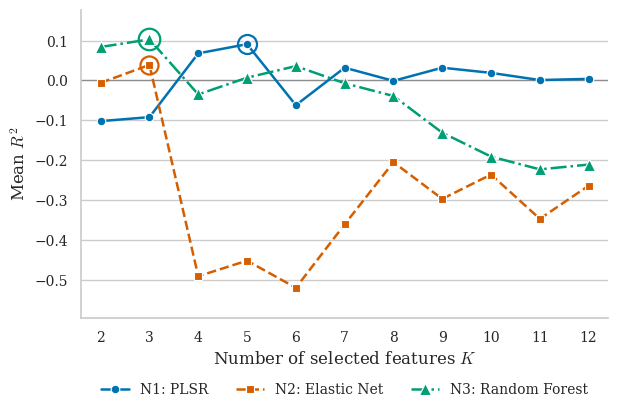

In [44]:
plot_k_sweeps({"N1: PLSR": N1, "N2: Elastic Net": N2, "N3: Random Forest": N3})

In [45]:
# Mean instead of max correlation (comparison only, not numbered in the thesis)
N1_mean = run("N1 (mean)", "PLSR, K sweep, mean correlation", X_compound, Y_quality, "pls", K_VALUES)
N2_mean = run("N2 (mean)", "Multi-task Elastic Net, K sweep, mean correlation", X_compound, Y_quality, "enet", K_VALUES)
N3_mean = run("N3 (mean)", "Random Forest, K sweep, mean correlation", X_compound, Y_quality, "rf", K_VALUES)

N1 (mean): PLSR, K sweep, mean correlation
K = 12 | Mean R2 = 0.096 | Mean MAE = 0.603


,R2,MAE,RMSE
Target,,,
Processed Taste,0.351,0.904,1.284
Degree of Artificiality,0.324,0.901,1.277
Condition,0.226,0.388,0.489
Interest,0.121,0.546,0.700
Satisfaction,0.112,0.589,0.755
Development,0.037,0.301,0.344
Balance,0.023,0.467,0.656
Complexity,-0.041,0.632,0.853
Length,-0.292,0.702,0.866


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.393,-0.107,-0.096,-0.131,-0.105,-0.118,-0.096,-0.044,-0.094,-0.007,0.096


Most frequent number of PLS components: 1 (11/12 folds)
Feature selection frequency:


...

,R2,MAE,RMSE
Target,,,
Processed Taste,0.288,1.003,1.345
Degree of Artificiality,0.267,1.017,1.330
Development,0.180,0.269,0.318
Condition,-0.048,0.483,0.570
Balance,-0.187,0.571,0.723
Interest,-0.215,0.616,0.823
Satisfaction,-0.221,0.740,0.885
Complexity,-0.322,0.719,0.961
Length,-0.368,0.739,0.891


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.278,-0.104,-0.134,-0.154,-0.149,-0.134,-0.145,-0.082,-0.093,-0.07,-0.088


Feature selection frequency:


,Folds selected
springiness,12
fat,12
resilience,12
moisture,12
umami aftertaste,12
complex viscosity,11
roughness as cut (wet),11
bitter,10
COF forward (wet),7
cohesiveness,7


### 10.2 GC-MS as odour groups (N4)

Some odour groups are zero in most trials and can be constant within an inner training
block. `rank_safe=True` drops such columns for that block and limits the number of PLS
components to the rank of the block. The setting of each model is the one used for the
reported results.

In [46]:
N4 = run("N4", "PLSR, K sweep, odour groups", X_flavour, Y_quality, "pls", K_VALUES,
         agg="max", rank_safe=True)

N4: PLSR, K sweep, odour groups
K = 6 | Mean R2 = 0.237 | Mean MAE = 0.573


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.749,0.625,0.778
Processed Taste,0.671,0.792,0.915
Satisfaction,0.288,0.557,0.676
Condition,0.281,0.431,0.472
Balance,0.248,0.464,0.576
Interest,0.021,0.632,0.739
Development,-0.018,0.295,0.354
Length,-0.042,0.651,0.777
Complexity,-0.067,0.710,0.864


Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-13.194,-23.039,0.226,0.161,0.237,0.208,0.219,0.036,0.166,0.141,0.161


Most frequent number of PLS components: 1 (10/12 folds)
Feature selection frequency:


,Folds selected
fat,12
other/unknown,12
umami aftertaste,12
umami,12
dairy,11
moisture,7
springiness,1
salty (odour),1
glass transition temperature,1
sour,1


### 10.3 Two sub-groups of targets (N5, reference model)

Separate models for the off-flavour targets (Processed Taste, Degree of Artificiality)
and the seven holistic targets, each with its own K.

In [47]:
N5 = run_subgroups("N5", "PLSR, two sub-groups, odour groups", X_flavour, Y_quality)

N5: PLSR, two sub-groups, odour groups
K = 5; 12 | Mean R2 = 0.285 | Mean MAE = 0.509


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.788,0.569,0.715
Processed Taste,0.734,0.669,0.822
Condition,0.420,0.317,0.424
Interest,0.248,0.520,0.647
Satisfaction,0.213,0.541,0.711
Balance,0.174,0.449,0.604
Complexity,0.139,0.593,0.776
Development,-0.064,0.300,0.362
Length,-0.088,0.624,0.794


Sub-group off-flavour: K = 5 | Mean R2 = 0.761 | Mean MAE = 0.619
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.66,0.599,0.731,0.761,0.741,0.719,0.715,0.621,0.605,0.574,0.608


Most frequent number of PLS components: 1 (11/12 folds)
Feature selection frequency:


,Folds selected
fat,12
other/unknown,12
umami aftertaste,12
dairy,11
umami,9
glass transition temperature,1
moisture,1
sour,1
oiling,1


Sub-group holistic: K = 12 | Mean R2 = 0.149 | Mean MAE = 0.478
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.327,-0.1,-0.024,-0.067,-0.123,-0.05,0.029,0.057,0.08,0.108,0.149


Most frequent number of PLS components: 1 (11/12 folds)
Feature selection frequency:


,Folds selected
springiness,12
dairy,12
resilience,12
salty (odour),12
other/unknown,11
moisture,11
fat,11
complex viscosity,11
roughness as cut (wet),10
COF forward (wet),9


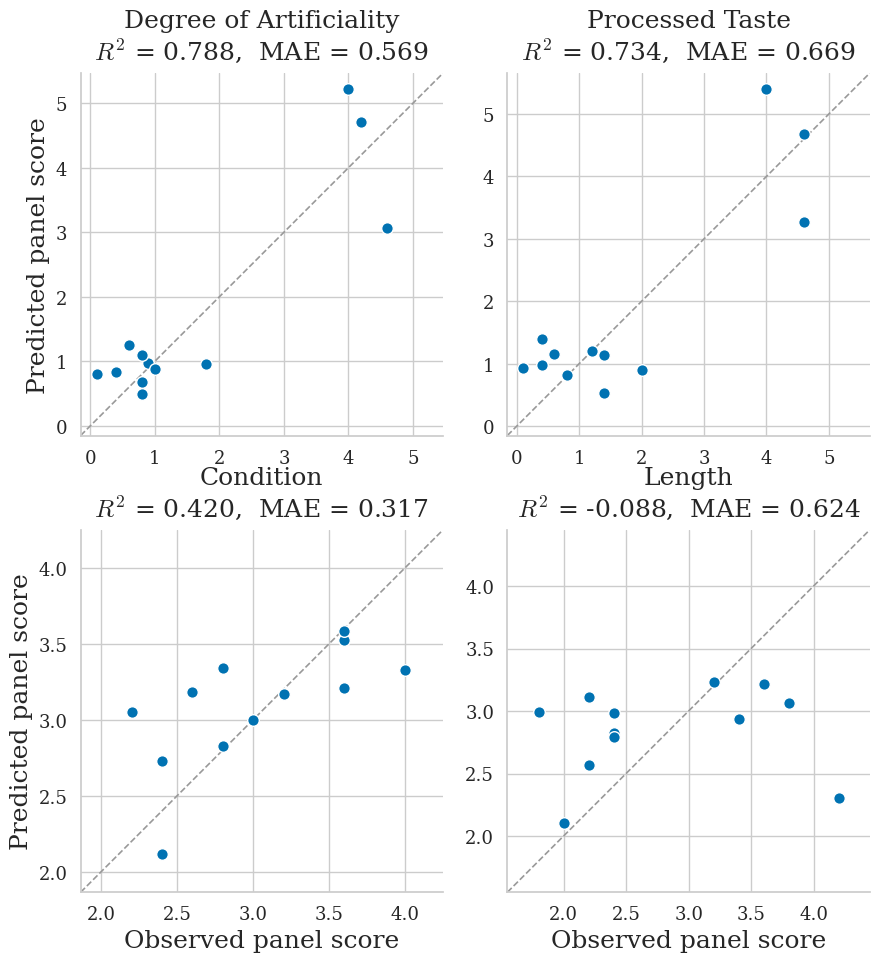

In [48]:
plot_predicted_vs_observed(N5, ["Degree of Artificiality", "Processed Taste", "Condition", "Length"],
                           ncols=2)

**Coefficients of N5.** Both sub-models are refitted on all twelve trials with their
stable features and the most frequent number of components. This fit is not cross-validated.

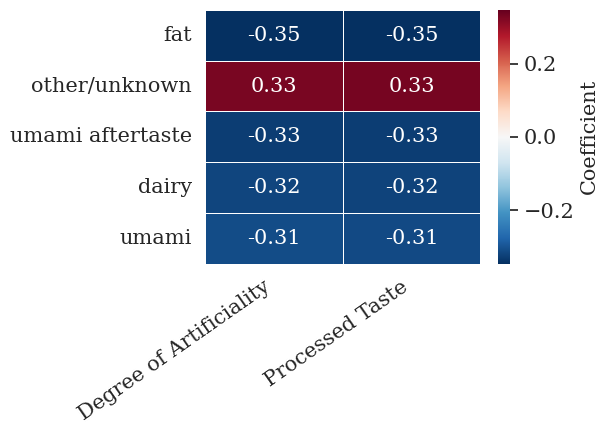

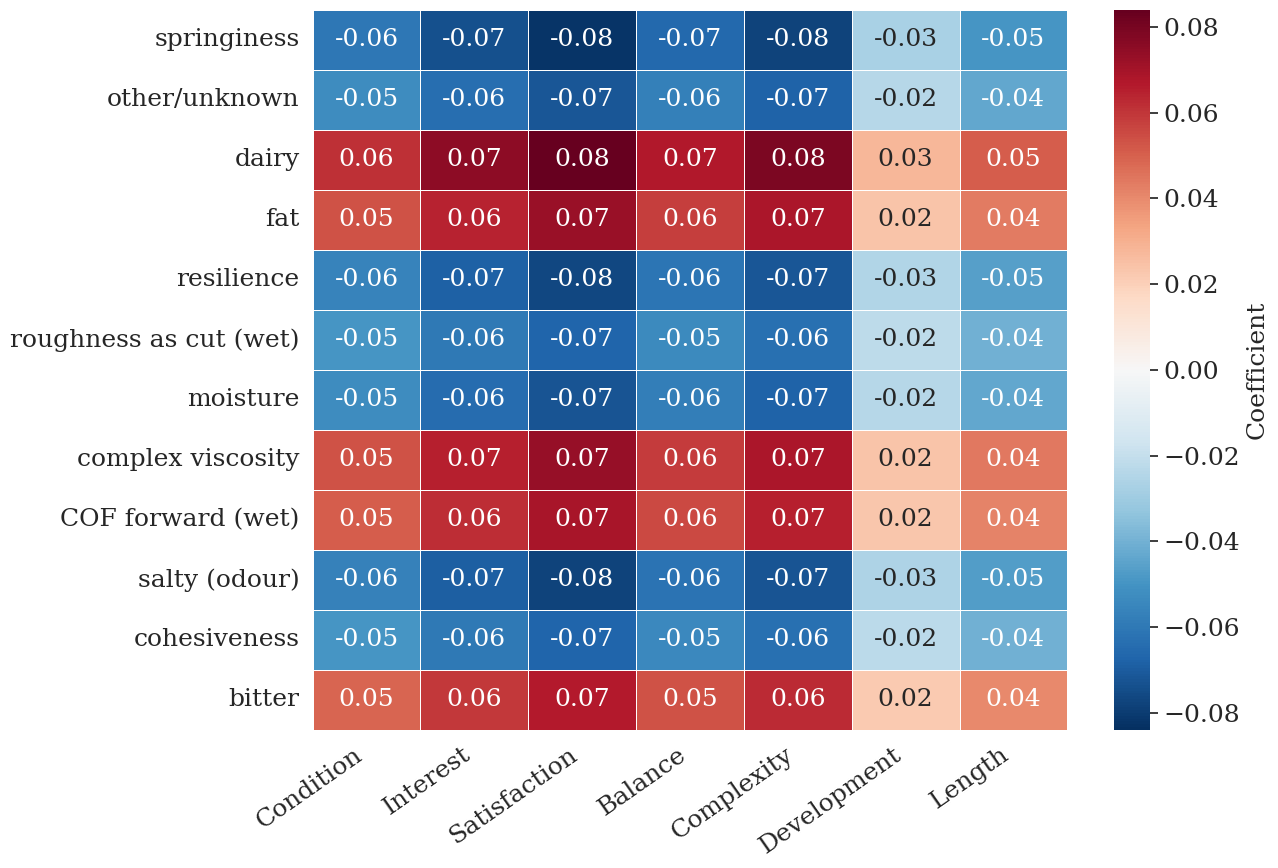

In [49]:
for part, fontsize in zip(N5["parts"].values(), [15, 18]):
    columns, n = pls_setup(X_flavour[stable_features(part)], most_frequent(part["n_components"]),
                           rank_safe=True)
    pls = scaled(PLSRegression(n_components=max(1, n))).fit(X_flavour[columns], part["Y"])
    coefs = pd.DataFrame(pls[-1].coef_.T, index=columns, columns=part["Y"].columns)
    plot_coefficients(coefs[part["scores"].index], fontsize)

### 10.4 Contribution of each modality (N6 to N13)

The reference model N5 is repeated without one modality and with one modality only.

In [50]:
N6 = run_subgroups("N6", "PLSR, two sub-groups, without physical",
                   X_flavour.drop(columns=physical.columns), Y_quality)
N7 = run_subgroups("N7", "PLSR, two sub-groups, physical only",
                   X_flavour[physical.columns], Y_quality)

N6: PLSR, two sub-groups, without physical
K = 4; 12 | Mean R2 = 0.324 | Mean MAE = 0.474


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.849,0.457,0.603
Processed Taste,0.832,0.514,0.653
Condition,0.398,0.349,0.432
Balance,0.372,0.437,0.526
Satisfaction,0.343,0.517,0.649
Interest,0.233,0.480,0.654
Complexity,0.191,0.529,0.752
Length,-0.046,0.667,0.779
Development,-0.252,0.317,0.393


Sub-group off-flavour: K = 4 | Mean R2 = 0.841 | Mean MAE = 0.486
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.819,0.822,0.841,0.762,0.76,0.445,0.614,0.462,0.69,0.651,0.737


Most frequent number of PLS components: 1 (12/12 folds)
Feature selection frequency:


...

,Folds selected
fat,12
moisture,11
springiness,11
resilience,7
melting speed,2
glass transition temperature,2
oiling,1
chewiness,1
hardness,1


Sub-group holistic: K = 12 | Mean R2 = 0.238 | Mean MAE = 0.464
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.021,-0.065,0.133,0.168,0.086,0.068,0.144,0.186,0.156,0.224,0.238


Most frequent number of PLS components: 1 (12/12 folds)
Feature selection frequency:


,Folds selected
springiness,12
fat,12
resilience,12
moisture,12
complex viscosity,12
cohesiveness,12
chewiness,12
adhesiveness,11
hardness,10
melting,9


In [51]:
N8 = run_subgroups("N8", "PLSR, two sub-groups, without E-tongue",
                   X_flavour.drop(columns=etongue.columns), Y_quality, rank_safe=True)
N9 = run_subgroups("N9", "PLSR, two sub-groups, E-tongue only",
                   X_flavour[etongue.columns], Y_quality, rank_safe=True)

N8: PLSR, two sub-groups, without E-tongue
K = 5; 11 | Mean R2 = 0.297 | Mean MAE = 0.524


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.802,0.580,0.692
Processed Taste,0.670,0.800,0.916
Condition,0.469,0.297,0.406
Interest,0.223,0.539,0.658
Satisfaction,0.207,0.536,0.713
Balance,0.159,0.443,0.609
Complexity,0.125,0.615,0.782
Development,0.089,0.277,0.335
Length,-0.067,0.626,0.787


Sub-group off-flavour: K = 5 | Mean R2 = 0.736 | Mean MAE = 0.690
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.521,0.626,0.698,0.736,0.607,0.645,0.62,0.596,0.522,0.553,0.606


Most frequent number of PLS components: 1 (9/12 folds)
Feature selection frequency:


...

,Folds selected
umami aftertaste,12
umami,11
sour,1


Sub-group holistic: K = 8 | Mean R2 = 0.150 | Mean MAE = 0.496
Mean R2 per K:


K,2,3,4,5,6,7,8
Mean R2,-0.191,-0.227,-0.123,0.045,0.119,0.115,0.15


Most frequent number of PLS components: 1 (12/12 folds)
Feature selection frequency:


,Folds selected
umami aftertaste,12
astringent,12
bitter,12
umami,12
salty,12
bitter aftertaste,12
sour,12
astringent aftertaste,12


In [52]:
N10 = run_subgroups("N10", "PLSR, two sub-groups, without tribology",
                    X_flavour.drop(columns=tribology.columns), Y_quality, rank_safe=True)
N11 = run_subgroups("N11", "PLSR, two sub-groups, tribology only",
                    X_flavour[tribology.columns], Y_quality, rank_safe=True)

N10: PLSR, two sub-groups, without tribology
K = 5; 10 | Mean R2 = 0.282 | Mean MAE = 0.507


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.788,0.569,0.715
Processed Taste,0.734,0.669,0.822
Condition,0.373,0.353,0.441
Interest,0.266,0.482,0.639
Satisfaction,0.199,0.559,0.717
Balance,0.136,0.478,0.617
Complexity,0.123,0.586,0.783
Length,0.076,0.562,0.732
Development,-0.157,0.309,0.377


Sub-group off-flavour: K = 5 | Mean R2 = 0.761 | Mean MAE = 0.619
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.273,-1.613,0.731,0.761,0.741,0.734,0.687,0.652,0.598,0.562,0.618


Most frequent number of PLS components: 1 (11/12 folds)
Feature selection frequency:


...

,Folds selected
roughness as cut (wet),12
roughness as cut (dry),12
volume (wet),12
width (dry),12
COF forward (wet),12
wear scar roughness (wet),12
volume (dry),12
width (wet),12
depth (wet),11
COF (wet),9


Sub-group holistic: K = 12 | Mean R2 = 0.110 | Mean MAE = 0.544
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,-0.338,-0.256,0.072,0.014,-0.002,0.028,0.029,-0.045,0.047,0.047,0.11


Most frequent number of PLS components: 1 (11/12 folds)
Feature selection frequency:


,Folds selected
roughness as cut (wet),12
COF forward (wet),12
roughness as cut (dry),12
width (dry),12
wear scar roughness (wet),12
COF (dry),12
volume (wet),12
depth (wet),12
COF backward (dry),11
COF (wet),11


In [53]:
N12 = run_subgroups("N12", "PLSR, two sub-groups, without GC-MS",
                    X_flavour.drop(columns=odour_groups.columns), Y_quality, rank_safe=True)
N13 = run_subgroups("N13", "PLSR, two sub-groups, GC-MS only",
                    X_flavour[odour_groups.columns], Y_quality, rank_safe=True)

N12: PLSR, two sub-groups, without GC-MS
K = 5; 11 | Mean R2 = 0.207 | Mean MAE = 0.576


,R2,MAE,RMSE
Target,,,
Degree of Artificiality,0.525,0.882,1.071
Processed Taste,0.524,0.839,1.100
Condition,0.381,0.329,0.438
Interest,0.188,0.533,0.673
Satisfaction,0.092,0.609,0.763
Complexity,0.078,0.596,0.803
Development,0.070,0.275,0.338
Balance,0.027,0.485,0.655
Length,-0.020,0.632,0.769


Sub-group off-flavour: K = 5 | Mean R2 = 0.524 | Mean MAE = 0.861
Mean R2 per K:


K,2,3,4,5,6,7,8,9,10,11,12
Mean R2,0.166,0.375,0.385,0.524,0.426,0.433,0.315,0.395,0.394,0.232,0.325


Most frequent number of PLS components: 1 (6/12 folds)
Feature selection frequency:


...

,Folds selected
other/unknown,12
dairy,12
salty (odour),12
mineral/chemical,12
fruity/floral,12
acid,12
sweet,12
animal/fungal/fermented,7
vegetable leaf/herbaceous,5


Sub-group holistic: K = 3 | Mean R2 = 0.175 | Mean MAE = 0.493
Mean R2 per K:


K,2,3,4,5,6,7,8,9
Mean R2,0.166,0.175,0.082,0.076,0.14,0.121,0.078,0.096


Most frequent number of PLS components: 1 (12/12 folds)
Feature selection frequency:


,Folds selected
dairy,12
salty (odour),12
other/unknown,11
sweet,1


## 11 Summary

In [54]:
summary = pd.DataFrame.from_dict({
    name: {"Description": result["description"],
           "K": "all" if result["k"] is None else result["k"],
           "Mean R2": round(result["scores"]["R2"].mean(), 3),
           "Mean MAE": round(result["scores"]["MAE"].mean(), 3)}
    for name, result in MODELS.items()
}, orient="index")
display(summary)

# R2 per target
for prefix in ("M", "N"):
    display(pd.DataFrame({name: result["scores"]["R2"]
                          for name, result in MODELS.items() if name.startswith(prefix)}))

,Description,K,Mean R2,Mean MAE
M1,"Ridge, no feature selection",all,0.033,0.382
M2,"Multi-task Elastic Net, no feature selection",all,0.094,0.365
M3,"PLSR, no feature selection",all,0.034,0.372
M4,"Multi-task Elastic Net, K sweep",3,0.269,0.334
M5,"PLSR, K sweep",9,0.206,0.334
M6,"Random Forest, K sweep",9,0.240,0.349
M7,"Multi-task Elastic Net, K sweep, odour groups",3,0.269,0.334
M8,"Single-task Elastic Net, K per target, odour groups",per target,0.177,0.345
M9,"Multi-task Elastic Net, K sweep, without physical",3,-0.493,0.487
M10,"Multi-task Elastic Net, K sweep, physical only",3,0.269,0.334


,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M4 (max),M4 (no CV)
Target,,,,,,,,,,,,,,
Acid/Sour,0.194,0.416,0.349,0.700,0.682,0.482,0.700,0.711,-0.527,0.700,0.046,0.668,0.680,0.809
Bitter,-0.371,-0.038,0.036,-0.064,0.096,0.179,-0.064,0.107,-0.714,-0.064,-0.214,0.098,0.081,0.334
Nose Aroma Intensity,-0.108,-0.153,-0.687,0.346,-0.441,0.083,0.346,-0.104,-0.266,0.346,-0.611,-0.315,0.004,0.704
Palate Intensity,0.143,0.259,-0.035,0.331,0.374,0.334,0.331,0.593,-0.500,0.331,-0.351,0.385,0.296,0.632
Salt,-0.013,0.097,0.242,0.233,0.394,0.402,0.233,-0.139,-0.645,0.233,-0.296,0.430,0.378,0.592
Savoury/Umami,0.072,-0.056,0.333,0.217,0.330,0.078,0.217,-0.082,-0.573,0.217,-0.176,0.359,0.264,0.525
Sweet,-0.001,-0.338,-0.340,-0.319,-0.487,-0.278,-0.319,-0.345,-0.128,-0.319,-0.615,-0.435,-0.222,0.429
Trigeminal Intensity,0.350,0.564,0.375,0.711,0.698,0.642,0.711,0.675,-0.593,0.711,0.140,0.733,0.691,0.811


,N1,N2,N3,N1 (mean),N2 (mean),N3 (mean),N4,N5,N6,N7,N8,N9,N10,N11,N12,N13
Target,,,,,,,,,,,,,,,,
Balance,0.075,0.137,0.131,0.023,-0.282,-0.187,0.248,0.174,0.372,0.086,0.159,0.264,0.136,0.240,0.027,0.345
Complexity,-0.138,-0.276,-0.070,-0.041,-0.483,-0.322,-0.067,0.139,0.191,0.214,0.125,0.138,0.123,0.161,0.078,0.105
Condition,0.075,-0.117,0.077,0.226,-0.019,-0.048,0.281,0.420,0.398,0.461,0.469,0.339,0.373,0.147,0.381,0.411
Degree of Artificiality,0.483,0.547,0.555,0.324,0.422,0.267,0.749,0.788,0.849,0.485,0.802,0.607,0.788,-0.132,0.525,0.821
Development,-0.054,-0.264,-0.491,0.037,-0.093,0.180,-0.018,-0.064,-0.252,0.230,0.089,-0.341,-0.157,-0.081,0.070,-0.154
Interest,-0.017,-0.008,-0.016,0.121,-0.352,-0.215,0.021,0.248,0.233,0.333,0.223,0.210,0.266,0.075,0.188,0.143
Length,-0.126,-0.105,0.030,-0.292,-0.749,-0.368,-0.042,-0.088,-0.046,0.116,-0.067,0.109,0.076,-0.043,-0.020,0.060
Processed Taste,0.380,0.260,0.413,0.351,0.327,0.288,0.671,0.734,0.832,0.358,0.670,0.332,0.734,-0.080,0.524,0.754
Satisfaction,0.144,0.181,0.299,0.112,-0.239,-0.221,0.288,0.213,0.343,0.224,0.207,0.333,0.199,0.271,0.092,0.312
